<a href="https://colab.research.google.com/github/altafmadni/Data_Projects/blob/main/Project%203/IT_Expenditure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data_path = "/content/IT Expenditure dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data')

In [7]:
df.shape

(81610, 12)

In [8]:
df.head()

,Date,Business Area,Region,Country,IT Sub Area,IT Area,Cost element name,Cost Element Group,Cost Element Sub Group,Actual,Forecast,Plan
0,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Inbound,Shared Services,Inbound Allocations,NaN,NaN,-5805.03
1,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,61.56,NaN,NaN
2,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,NaN,61.56,NaN
3,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Other Miscellaneous Expense,Other,Other,NaN,NaN,270.01
4,Jan,R&D,Europe,United Kingdom,Planning,BU Support,Regular Salaries And Wages,Labor,Internal Labor,NaN,NaN,-10692.07


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81610 entries, 0 to 81609
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    81610 non-null  object 
 1   Business Area           81610 non-null  object 
 2   Region                  81610 non-null  object 
 3   Country                 81610 non-null  object 
 4   IT Sub Area             81610 non-null  object 
 5   IT Area                 81610 non-null  object 
 6   Cost element name       81610 non-null  object 
 7   Cost Element Group      81610 non-null  object 
 8   Cost Element Sub Group  81610 non-null  object 
 9   Actual                  22884 non-null  float64
 10  Forecast                31691 non-null  float64
 11  Plan                    27035 non-null  float64
dtypes: float64(3), object(9)
memory usage: 7.5+ MB


In [10]:
df.describe()

,Actual,Forecast,Plan
count,2.288400e+04,3.169100e+04,2.703500e+04
mean,2.428470e+04,2.810080e+04,3.330506e+04
std,6.176167e+05,5.328571e+05,1.538172e+05
min,-6.891200e+07,-6.891200e+07,-4.401869e+05
25%,2.129225e+02,1.783700e+02,3.909300e+02
50%,1.796220e+03,1.551000e+03,2.681580e+03
75%,9.884015e+03,1.083300e+04,1.312500e+04
max,5.817300e+07,5.817300e+07,6.835258e+06


In [11]:
df.isnull().sum()

,0
Date,0
Business Area,0
Region,0
Country,0
IT Sub Area,0
IT Area,0
Cost element name,0
Cost Element Group,0
Cost Element Sub Group,0
Actual,58726


In [12]:
df.duplicated().sum()

np.int64(1929)

## Data Cleaning


In [13]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_")
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81610 entries, 0 to 81609
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    81610 non-null  object 
 1   business_area           81610 non-null  object 
 2   region                  81610 non-null  object 
 3   country                 81610 non-null  object 
 4   it_sub_area             81610 non-null  object 
 5   it_area                 81610 non-null  object 
 6   cost_element_name       81610 non-null  object 
 7   cost_element_group      81610 non-null  object 
 8   cost_element_sub_group  81610 non-null  object 
 9   actual                  22884 non-null  float64
 10  forecast                31691 non-null  float64
 11  plan                    27035 non-null  float64
dtypes: float64(3), object(9)
memory usage: 7.5+ MB


In [15]:
df['date']

,date
0,Jan
1,Jan
2,Jan
3,Jan
4,Jan
...,...
81605,Dec
81606,Dec
81607,Dec
81608,Dec


In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(79681, 12)

In [18]:
total_actual = df['actual'].sum()
total_forecast = df['forecast'].sum()
total_plan = df['plan'].sum()

In [19]:
total_actual
total_forecast
total_plan

np.float64(896453671.69)

In [20]:
actual_forecast = total_actual - total_forecast
actual_plan = total_actual - total_plan

## Analysis by Month

In [21]:
monthly_analysis = df.groupby('date')[['actual', 'forecast', 'plan']].sum().reset_index().sort_values('date').iloc[:8]

In [22]:
monthly_analysis

,date,actual,forecast,plan
0,Apr,66491911.47,6.649191e+07,75179842.26
1,Aug,69634706.01,8.089817e+07,70793181.40
2,Dec,0.00,7.402468e+07,72689510.18
3,Feb,65136533.00,6.513653e+07,72587016.00
4,Jan,58283846.66,5.828385e+07,86393188.69
5,Jul,72968028.34,8.093844e+07,76447444.61
6,Jun,75300420.92,7.530042e+07,78390781.99
7,Mar,73518933.25,7.351893e+07,77509984.33


In [23]:
monthly_analysis["actual_vs_forecast"] = (
    monthly_analysis["actual"] - monthly_analysis["forecast"]
)

monthly_analysis["actual_vs_plan"] = (
    monthly_analysis["actual"] - monthly_analysis["plan"]
)

In [24]:
# Convert the 'date' column (which contains month abbreviations like 'Jan', 'Feb')
# to actual datetime objects. Pandas will default to the current year and day 1.
monthly_analysis["date"] = pd.to_datetime(monthly_analysis["date"], format='%b')

# After converting to datetime, sort the DataFrame by the 'date' column
# to ensure chronological order for analysis and plotting.
monthly_analysis = monthly_analysis.sort_values(by="date").reset_index(drop=True)

# Now that 'date' is a datetime object, extract the month abbreviation
# into a new 'month' column using the .dt accessor.
monthly_analysis["month"] = monthly_analysis["date"].dt.strftime("%b")

In [25]:
monthly_analysis

,date,actual,forecast,plan,actual_vs_forecast,actual_vs_plan,month
0,1900-01-01,58283846.66,5.828385e+07,86393188.69,0.000000e+00,-28109342.03,Jan
1,1900-02-01,65136533.00,6.513653e+07,72587016.00,0.000000e+00,-7450483.00,Feb
2,1900-03-01,73518933.25,7.351893e+07,77509984.33,0.000000e+00,-3991051.08,Mar
3,1900-04-01,66491911.47,6.649191e+07,75179842.26,0.000000e+00,-8687930.79,Apr
4,1900-06-01,75300420.92,7.530042e+07,78390781.99,0.000000e+00,-3090361.07,Jun
5,1900-07-01,72968028.34,8.093844e+07,76447444.61,-7.970414e+06,-3479416.27,Jul
6,1900-08-01,69634706.01,8.089817e+07,70793181.40,-1.126346e+07,-1158475.39,Aug
7,1900-12-01,0.00,7.402468e+07,72689510.18,-7.402468e+07,-72689510.18,Dec


## Visualize the Monthly Analysis

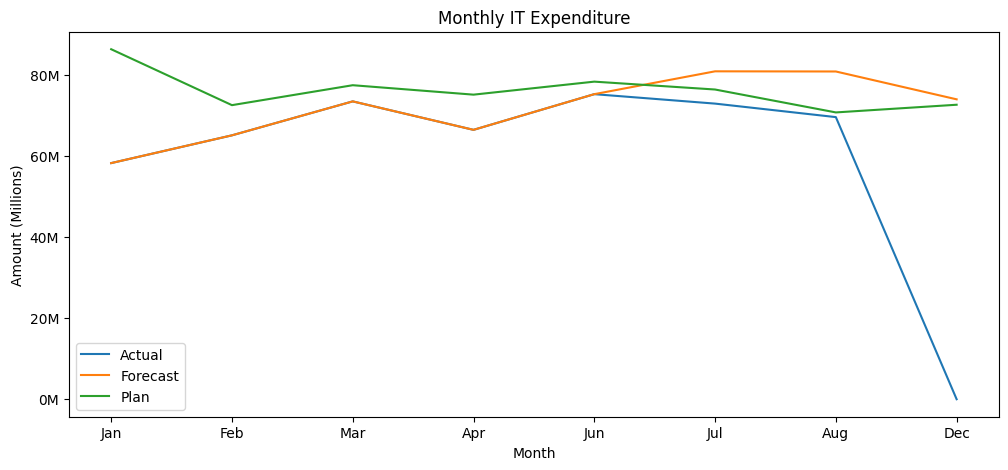

In [26]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))

plt.plot(monthly_analysis["month"], monthly_analysis["actual"], label="Actual")
plt.plot(monthly_analysis["month"], monthly_analysis["forecast"], label="Forecast")
plt.plot(monthly_analysis["month"], monthly_analysis["plan"], label="Plan")

plt.title("Monthly IT Expenditure")
plt.xlabel("Month")
plt.ylabel("Amount (Millions)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.legend()

plt.show()

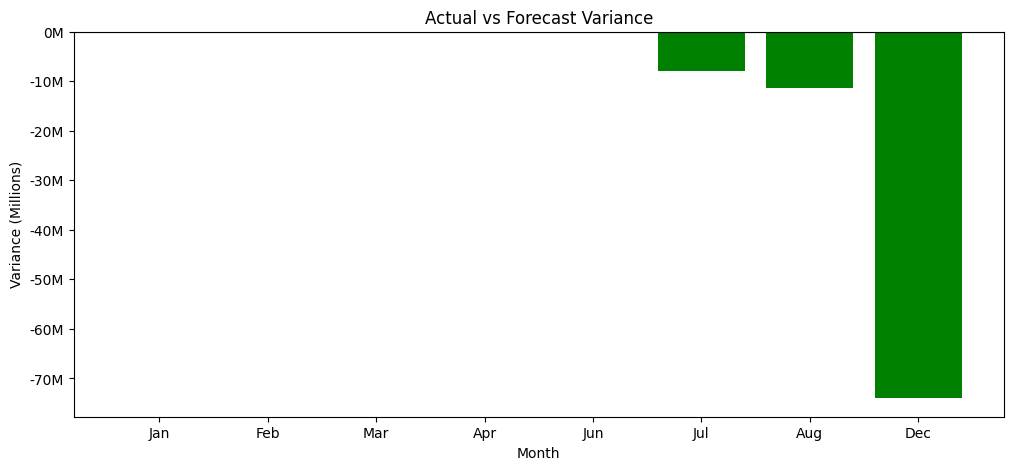

In [27]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))

plt.bar(monthly_analysis["month"], monthly_analysis["actual_vs_forecast"], color = 'green')

plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

plt.title("Actual vs Forecast Variance")
plt.xlabel("Month")
plt.ylabel("Variance (Millions)")

plt.show()

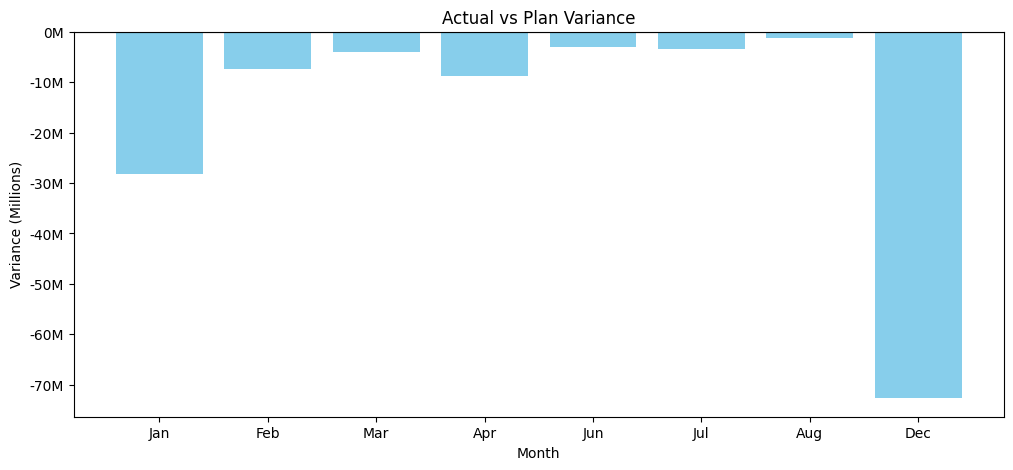

In [28]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))

plt.bar(monthly_analysis["month"], monthly_analysis["actual_vs_plan"], color = 'skyblue')

plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

plt.title("Actual vs Plan Variance")
plt.xlabel("Month")
plt.ylabel("Variance (Millions)")

plt.show()

In [29]:
monthly_analysis

,date,actual,forecast,plan,actual_vs_forecast,actual_vs_plan,month
0,1900-01-01,58283846.66,5.828385e+07,86393188.69,0.000000e+00,-28109342.03,Jan
1,1900-02-01,65136533.00,6.513653e+07,72587016.00,0.000000e+00,-7450483.00,Feb
2,1900-03-01,73518933.25,7.351893e+07,77509984.33,0.000000e+00,-3991051.08,Mar
3,1900-04-01,66491911.47,6.649191e+07,75179842.26,0.000000e+00,-8687930.79,Apr
4,1900-06-01,75300420.92,7.530042e+07,78390781.99,0.000000e+00,-3090361.07,Jun
5,1900-07-01,72968028.34,8.093844e+07,76447444.61,-7.970414e+06,-3479416.27,Jul
6,1900-08-01,69634706.01,8.089817e+07,70793181.40,-1.126346e+07,-1158475.39,Aug
7,1900-12-01,0.00,7.402468e+07,72689510.18,-7.402468e+07,-72689510.18,Dec


## Business Area Analysis

In [30]:
business_area = df.groupby('business_area')[['actual', 'forecast', 'plan']].sum().reset_index()

In [31]:
business_area

,business_area,actual,forecast,plan
0,BU,7.755242e+07,1.353501e+08,1.389139e+08
1,Distribution,3.288038e+07,5.229149e+07,5.177806e+07
2,Infrastructure,1.577270e+08,2.420254e+08,2.495678e+08
3,Manufacturing,8.665847e+07,1.337034e+08,1.304895e+08
4,Office & Administrative,1.111828e+08,1.723926e+08,1.726290e+08
5,R&D,6.553644e+07,1.146429e+08,1.134918e+08
6,Services,2.243617e+07,3.775176e+07,3.958379e+07


In [32]:
business_area['actual_vs_forecast'] = business_area['actual'] - business_area['forecast']
business_area['actual_vs_plan'] = business_area['actual'] - business_area['plan']

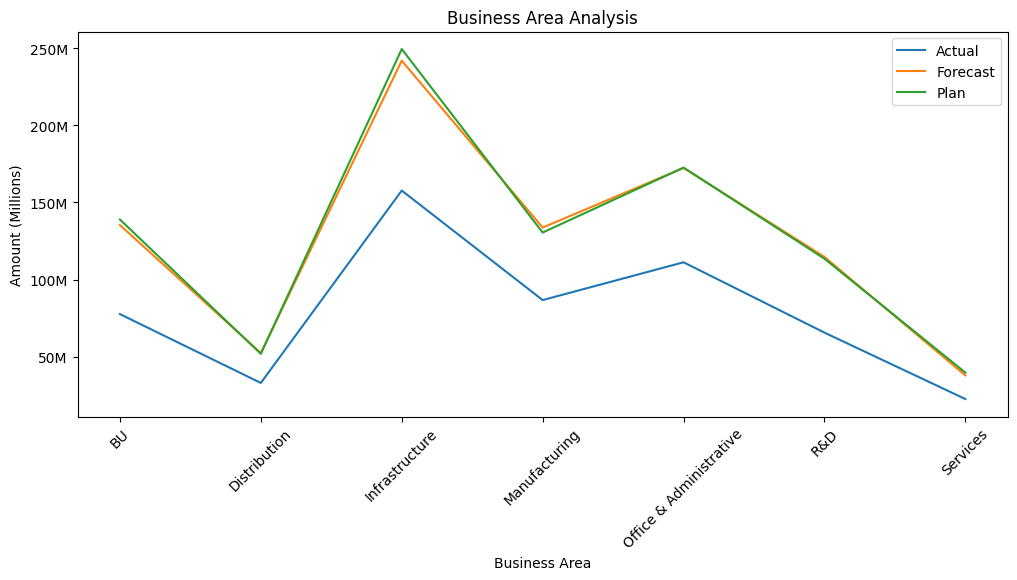

In [33]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))
plt.plot(business_area['business_area'], business_area['actual'], label="Actual")
plt.plot(business_area['business_area'], business_area['forecast'], label="Forecast")
plt.plot(business_area['business_area'], business_area['plan'], label="Plan")
plt.xticks(rotation=45)
plt.xlabel('Business Area')
plt.ylabel('Amount (Millions)')
plt.title('Business Area Analysis')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)
plt.legend()
plt.show()

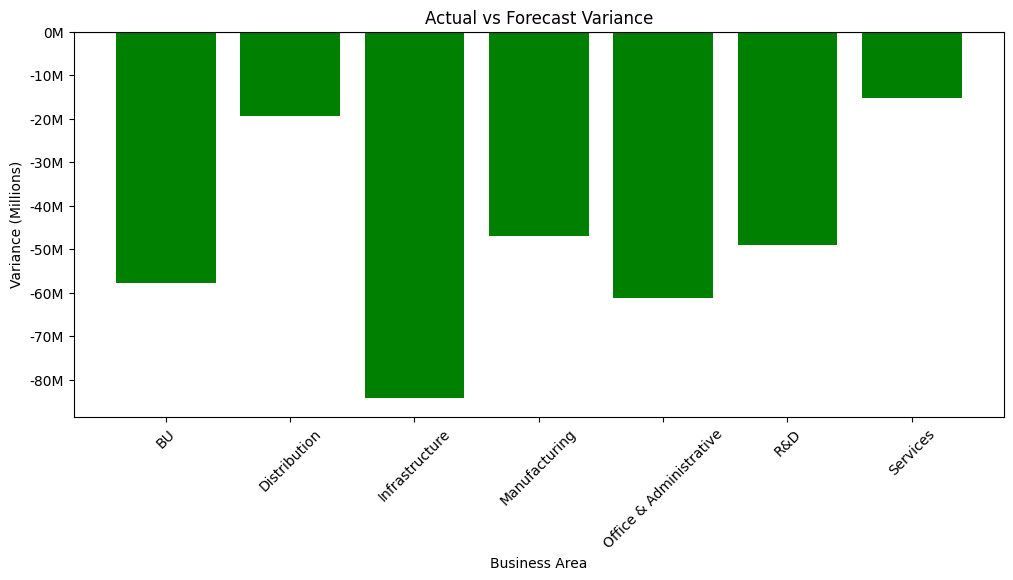

In [34]:
plt.figure(figsize=(12,5))
plt.bar(business_area['business_area'], business_area['actual_vs_forecast'], color = 'green')
plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.xlabel('Business Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Forecast Variance')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.show()

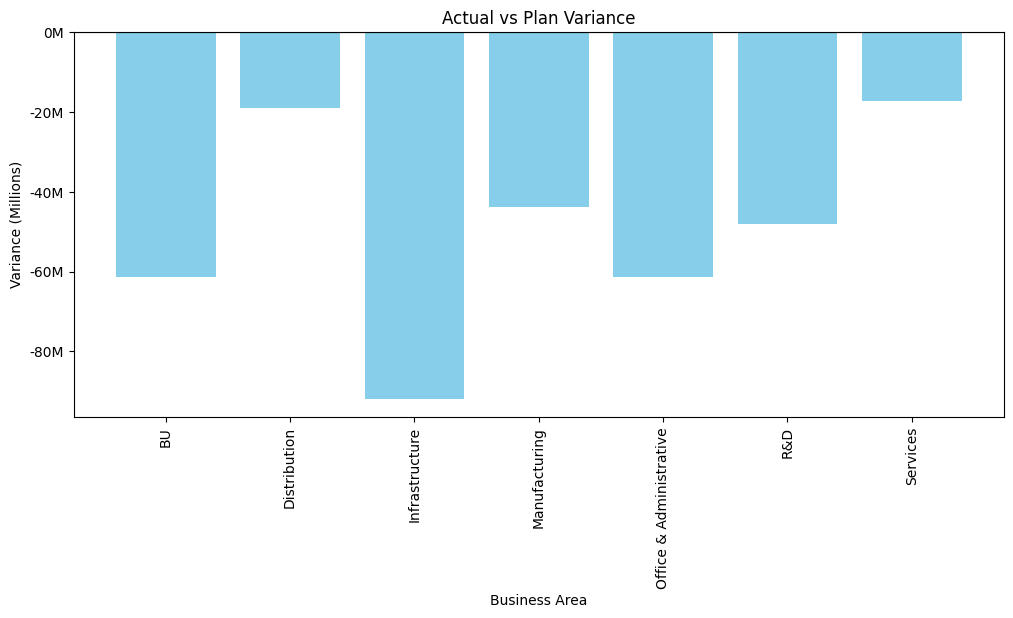

In [35]:
plt.figure(figsize=(12,5))
plt.bar(business_area['business_area'], business_area['actual_vs_plan'], color = 'skyblue')
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.xlabel('Business Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Plan Variance')

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.show()

## Country Analysis

In [36]:
country_analysis = df.groupby('country')[['actual','forecast','plan']].sum().reset_index()

In [37]:
country_analysis['actual_vs_forecast'] = country_analysis['actual'] - country_analysis['forecast']

country_analysis['actual_vs_plan'] = country_analysis['actual'] - country_analysis['plan']

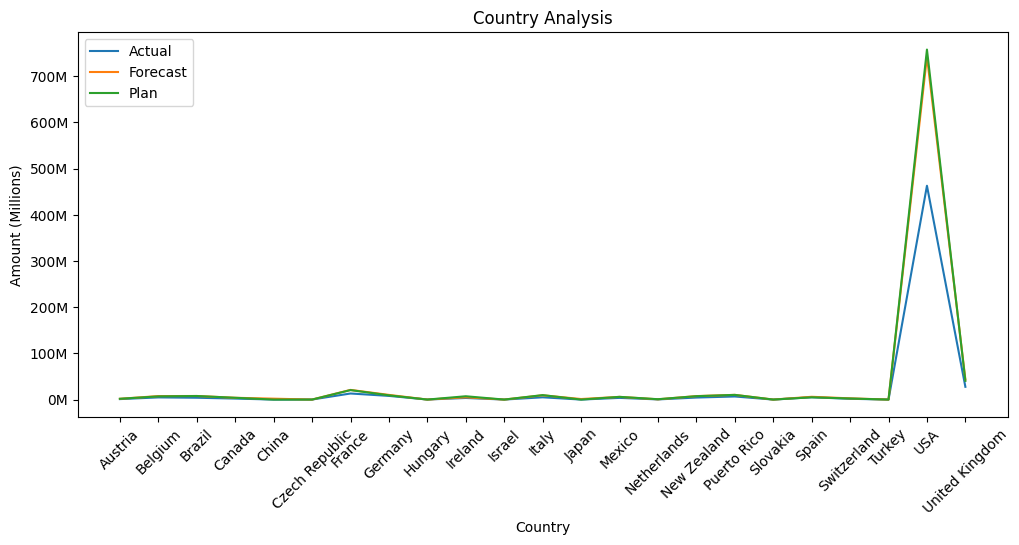

In [38]:
plt.figure(figsize=(12,5))
plt.plot(country_analysis['country'], country_analysis['actual'], label="Actual")
plt.plot(country_analysis['country'], country_analysis['forecast'], label="Forecast")
plt.plot(country_analysis['country'], country_analysis['plan'], label="Plan")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xlabel('Country')
plt.ylabel('Amount (Millions)')
plt.title('Country Analysis')
plt.legend()
plt.show()

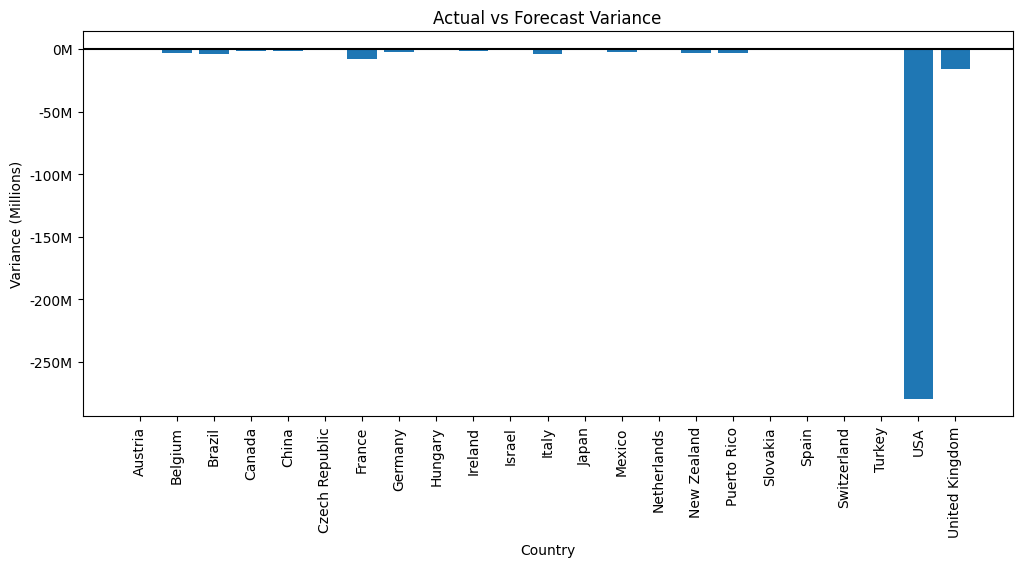

In [39]:
plt.figure(figsize=(12,5))
plt.bar(country_analysis['country'], country_analysis['actual_vs_forecast'])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Forecast Variance')
plt.show()

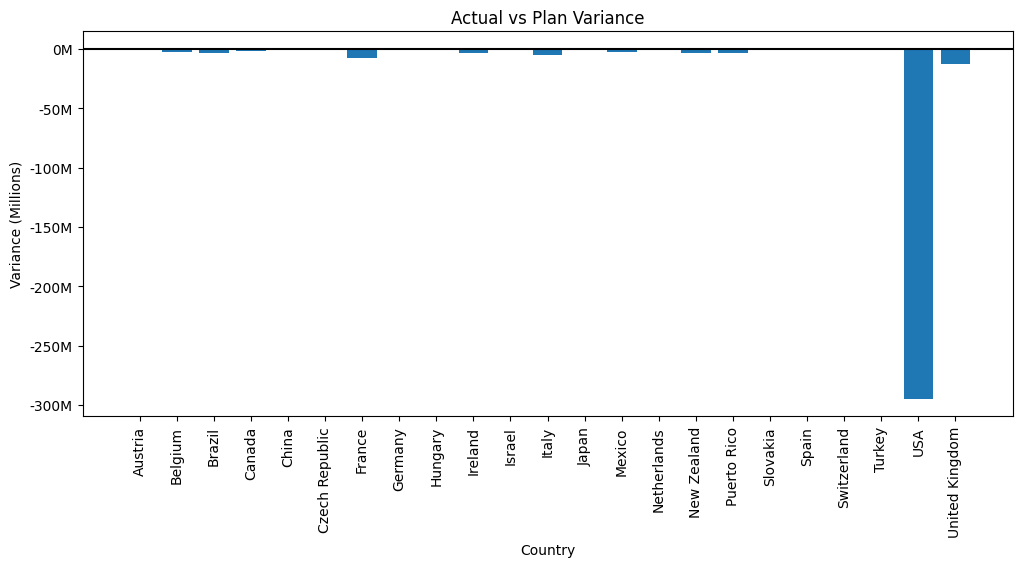

In [40]:
plt.figure(figsize=(12,5))
plt.bar(country_analysis['country'], country_analysis['actual_vs_plan'])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Plan Variance')
plt.show()

## IT Area Analysis

In [41]:
it_area_analysis = (
    df.groupby("it_area")[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

it_area_analysis["actual_vs_forecast"] = (
    it_area_analysis["actual"] - it_area_analysis["forecast"]
)

it_area_analysis["actual_vs_plan"] = (
    it_area_analysis["actual"] - it_area_analysis["plan"]
)

it_area_analysis = it_area_analysis.sort_values(
    by="actual",
    ascending=False
)

it_area_analysis

,it_area,actual,forecast,plan,actual_vs_forecast,actual_vs_plan
2,Functional,1.783799e+08,2.927620e+08,2.986306e+08,-1.143821e+08,-1.202506e+08
0,BU Support,1.625635e+08,2.633267e+08,2.568935e+08,-1.007632e+08,-9.432998e+07
4,Infrastructure,1.548086e+08,2.368272e+08,2.416131e+08,-8.201858e+07,-8.680447e+07
3,Governance,3.288056e+07,5.229167e+07,5.177806e+07,-1.941111e+07,-1.889751e+07
1,Enablement,2.534106e+07,4.294992e+07,4.753845e+07,-1.760886e+07,-2.219739e+07


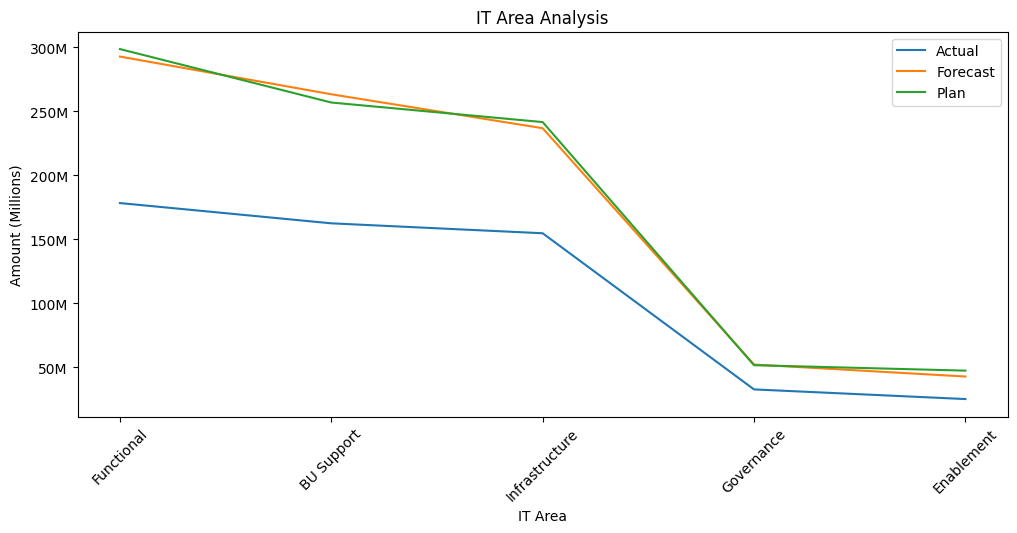

In [42]:
plt.figure(figsize=(12,5))
plt.plot(it_area_analysis["it_area"], it_area_analysis["actual"], label="Actual")
plt.plot(it_area_analysis["it_area"], it_area_analysis["forecast"], label="Forecast")
plt.plot(it_area_analysis["it_area"], it_area_analysis["plan"], label="Plan")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=45)
plt.xlabel('IT Area')
plt.ylabel('Amount (Millions)')
plt.title('IT Area Analysis')
plt.legend()
plt.show()

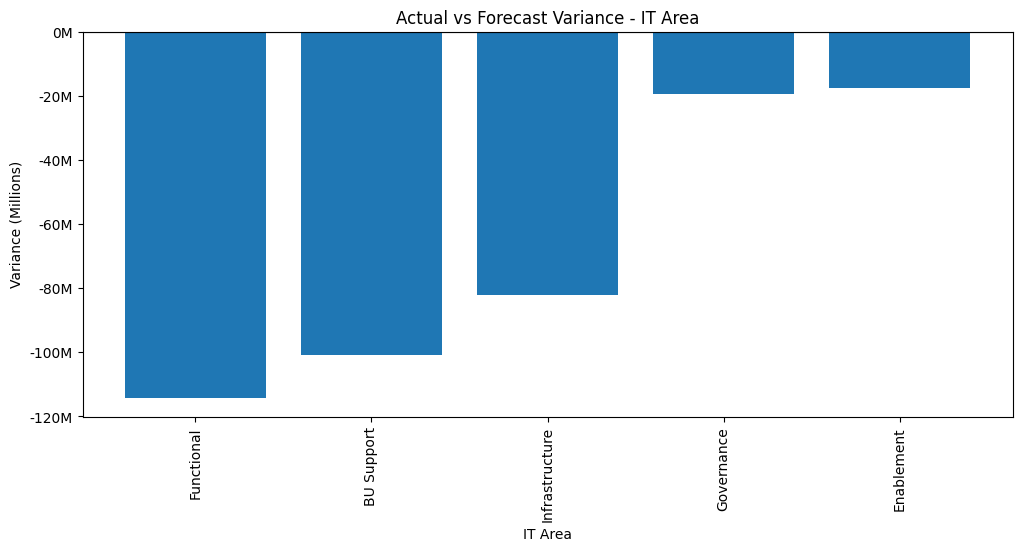

In [44]:
plt.figure(figsize=(12,5))
plt.bar(it_area_analysis["it_area"], it_area_analysis["actual_vs_forecast"])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('IT Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Forecast Variance - IT Area')
plt.show()

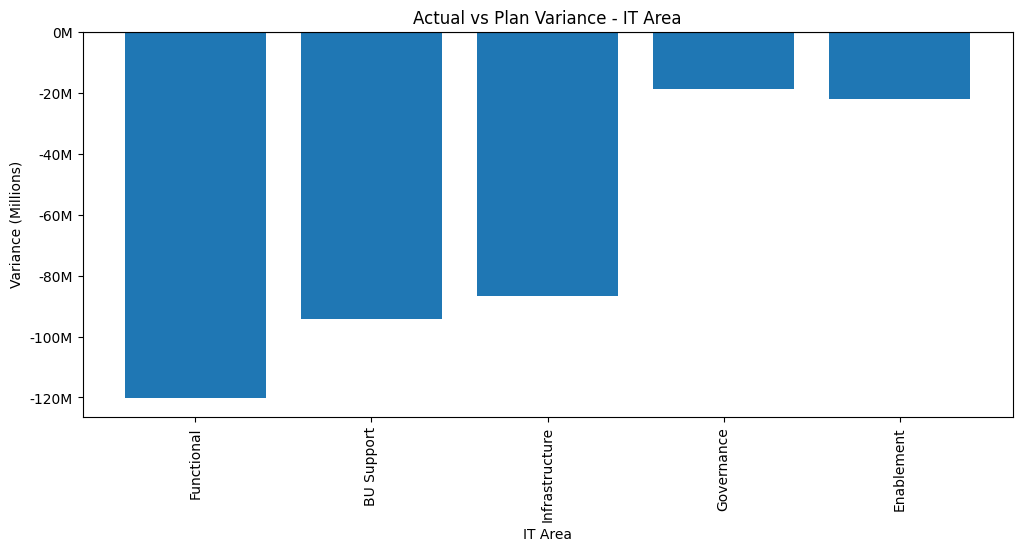

In [45]:
plt.figure(figsize=(12,5))
plt.bar(it_area_analysis["it_area"], it_area_analysis["actual_vs_plan"])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('IT Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Plan Variance - IT Area')
plt.show()

## IT Sub-Area Group

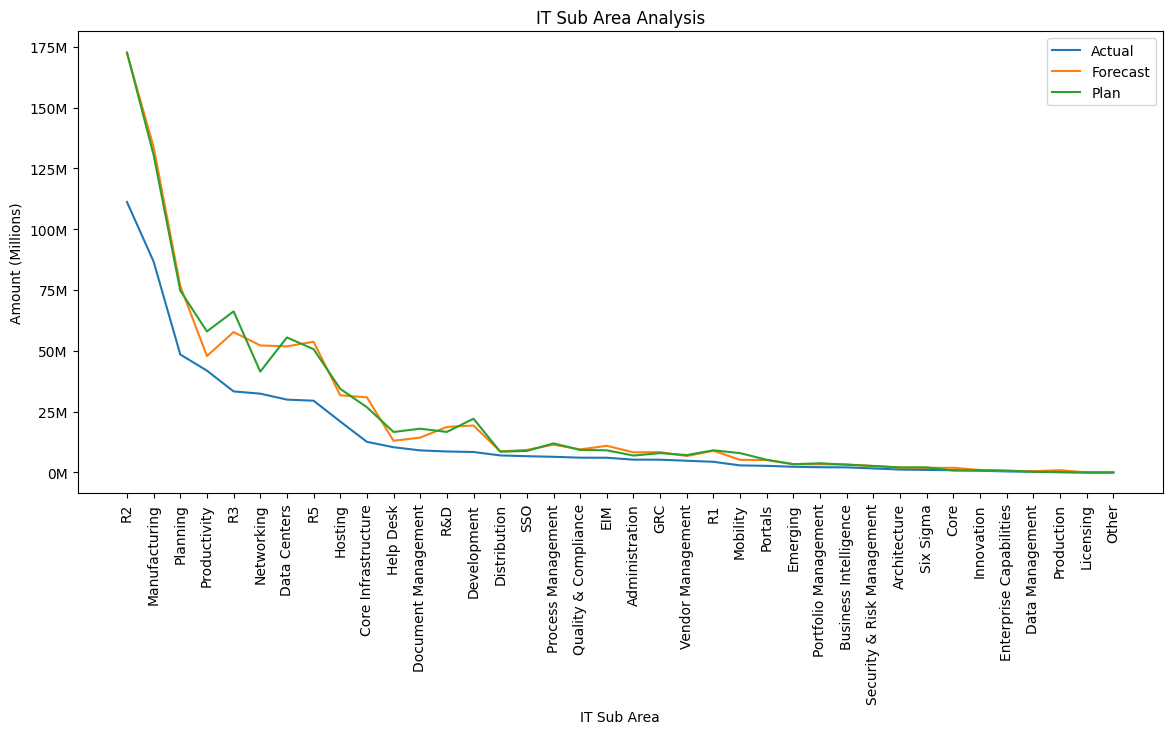

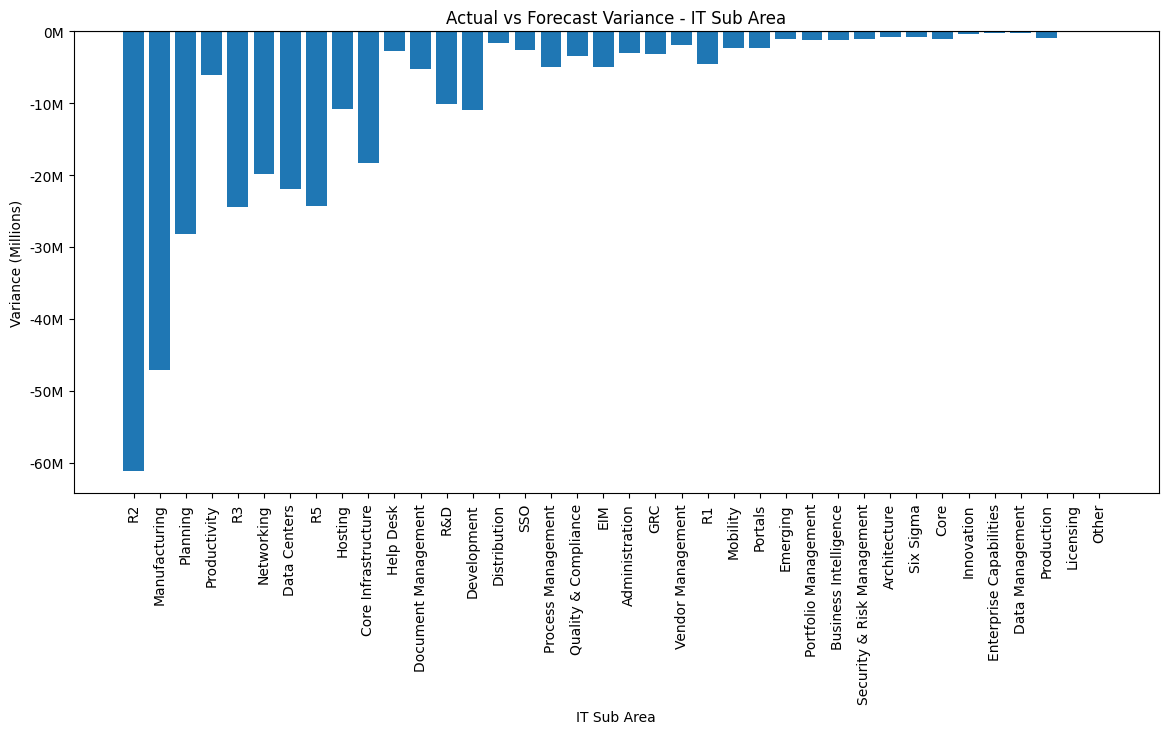

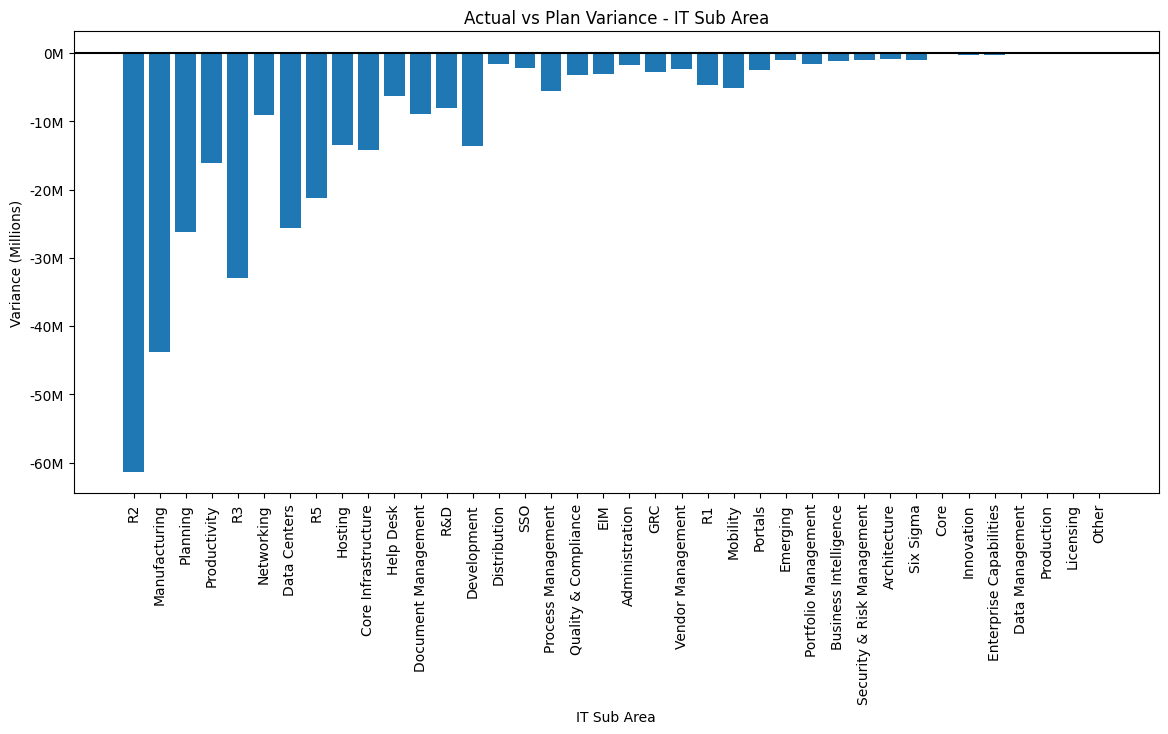

In [46]:
it_sub_area_analysis = (
    df.groupby("it_sub_area")[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

it_sub_area_analysis["actual_vs_forecast"] = (
    it_sub_area_analysis["actual"] - it_sub_area_analysis["forecast"]
)

it_sub_area_analysis["actual_vs_plan"] = (
    it_sub_area_analysis["actual"] - it_sub_area_analysis["plan"]
)

it_sub_area_analysis = it_sub_area_analysis.sort_values(
    by="actual",
    ascending=False
)

plt.figure(figsize=(14, 6))
plt.plot(it_sub_area_analysis["it_sub_area"], it_sub_area_analysis["actual"], label="Actual")
plt.plot(it_sub_area_analysis["it_sub_area"], it_sub_area_analysis["forecast"], label="Forecast")
plt.plot(it_sub_area_analysis["it_sub_area"], it_sub_area_analysis["plan"], label="Plan")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('IT Sub Area')
plt.ylabel('Amount (Millions)')
plt.title('IT Sub Area Analysis')
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(it_sub_area_analysis["it_sub_area"], it_sub_area_analysis["actual_vs_forecast"])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('IT Sub Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Forecast Variance - IT Sub Area')
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(it_sub_area_analysis["it_sub_area"], it_sub_area_analysis["actual_vs_plan"])
plt.axhline(0, color="black")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.xticks(rotation=90)
plt.xlabel('IT Sub Area')
plt.ylabel('Variance (Millions)')
plt.title('Actual vs Plan Variance - IT Sub Area')
plt.show()

## Cost Element Group Analysis

In [47]:
cost_element_group_analysis = (
    df.groupby("cost_element_group")[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

cost_element_group_analysis["actual_vs_forecast"] = (
    cost_element_group_analysis["actual"] - cost_element_group_analysis["forecast"]
)

cost_element_group_analysis["actual_vs_plan"] = (
    cost_element_group_analysis["actual"] - cost_element_group_analysis["plan"]
)

cost_element_group_analysis = cost_element_group_analysis.sort_values(
    by="actual",
    ascending=False
)

print(cost_element_group_analysis)

    cost_element_group        actual      forecast          plan  \
2                Labor  2.886620e+08  4.723917e+08  4.627597e+08   
0         Depr & Amort  1.343680e+08  2.054128e+08  2.182764e+08   
1  Hardware & Software  1.025693e+08  1.553136e+08  1.642864e+08   
3                Other  2.741295e+07  5.322287e+07  4.751655e+07   
4      Shared Services  9.613673e+05  1.816523e+06  3.614562e+06   

   actual_vs_forecast  actual_vs_plan  
2       -1.837297e+08   -1.740977e+08  
0       -7.104476e+07   -8.390838e+07  
1       -5.274430e+07   -6.171710e+07  
3       -2.580992e+07   -2.010360e+07  
4       -8.551555e+05   -2.653195e+06  


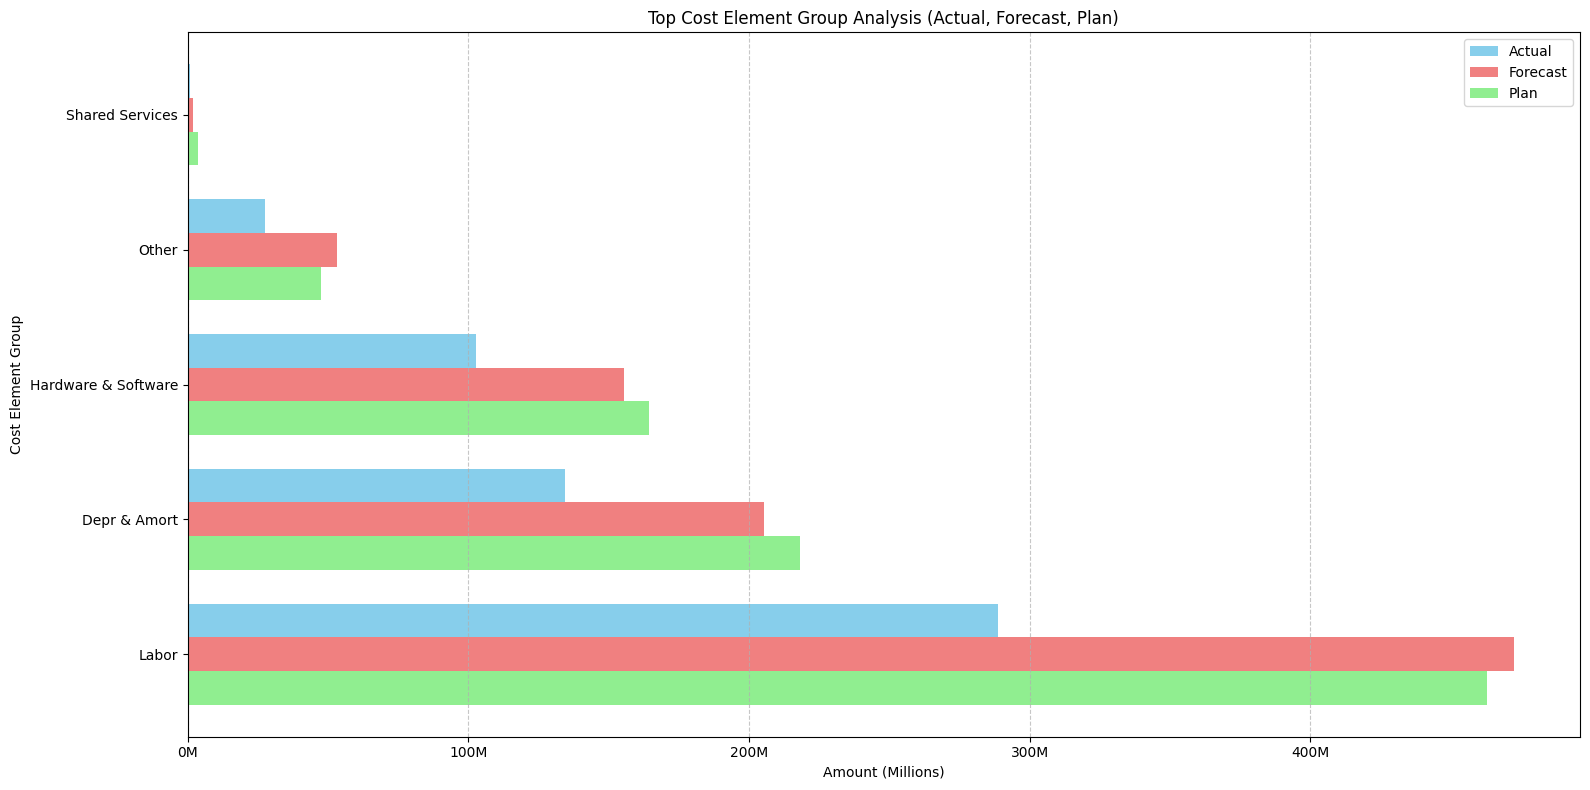

In [48]:
plt.figure(figsize=(16, 8))

top_cost_element_groups = cost_element_group_analysis.head(20)

bar_width = 0.25
index = np.arange(len(top_cost_element_groups))

plt.barh(index + bar_width, top_cost_element_groups["actual"], bar_width, label="Actual", color='skyblue')
plt.barh(index, top_cost_element_groups["forecast"], bar_width, label="Forecast", color='lightcoral')
plt.barh(index - bar_width, top_cost_element_groups["plan"], bar_width, label="Plan", color='lightgreen')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.yticks(index, top_cost_element_groups["cost_element_group"])
plt.ylabel('Cost Element Group')
plt.xlabel('Amount (Millions)')
plt.title('Top Cost Element Group Analysis (Actual, Forecast, Plan)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

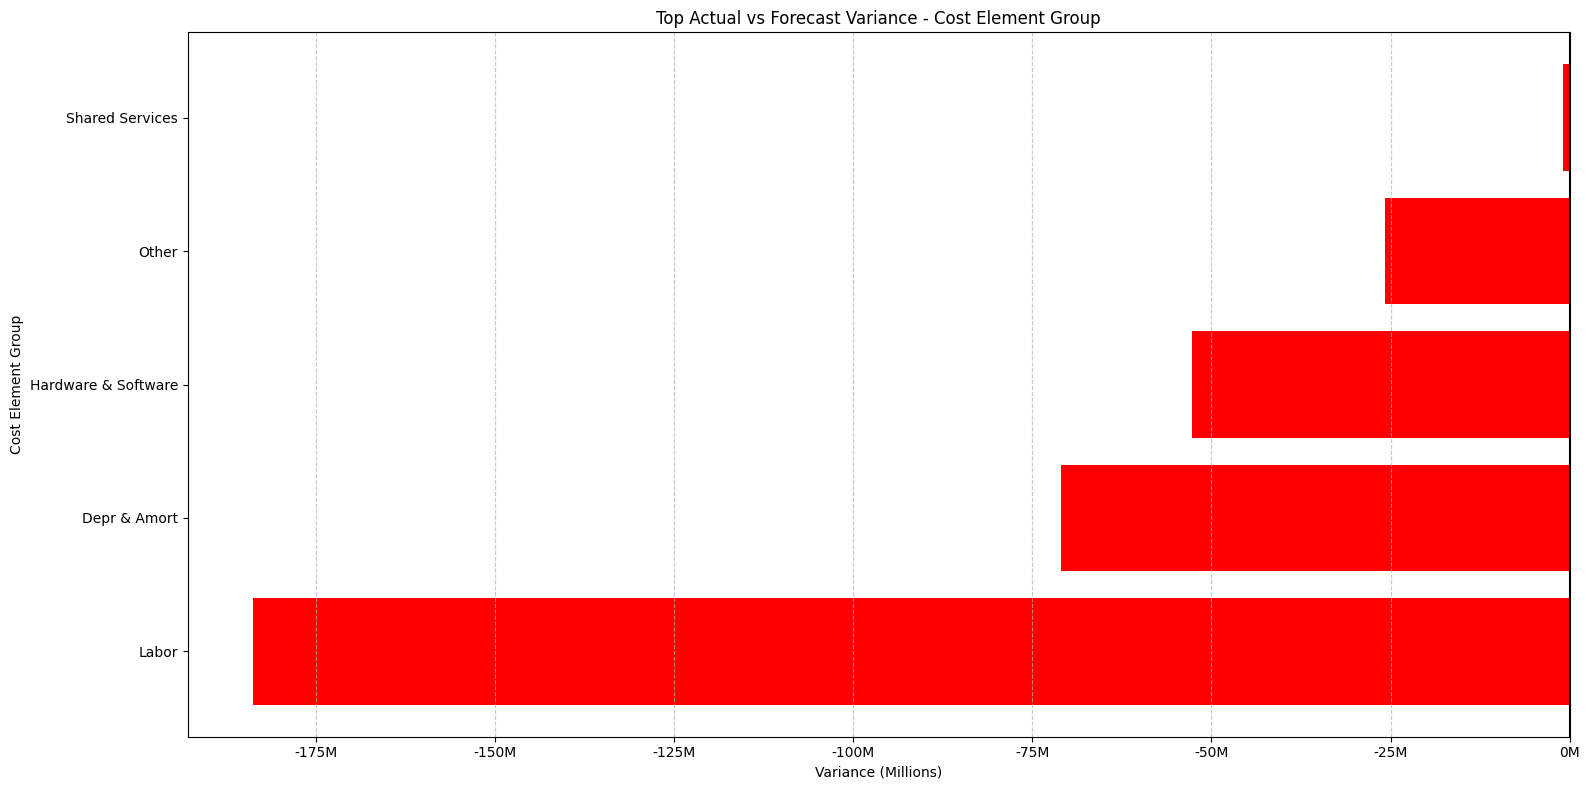

In [49]:
plt.figure(figsize=(16, 8))

top_cost_element_groups = cost_element_group_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_cost_element_groups["actual_vs_forecast"]]
plt.barh(top_cost_element_groups["cost_element_group"], top_cost_element_groups["actual_vs_forecast"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Group')
plt.xlabel('Variance (Millions)')
plt.title('Top Actual vs Forecast Variance - Cost Element Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

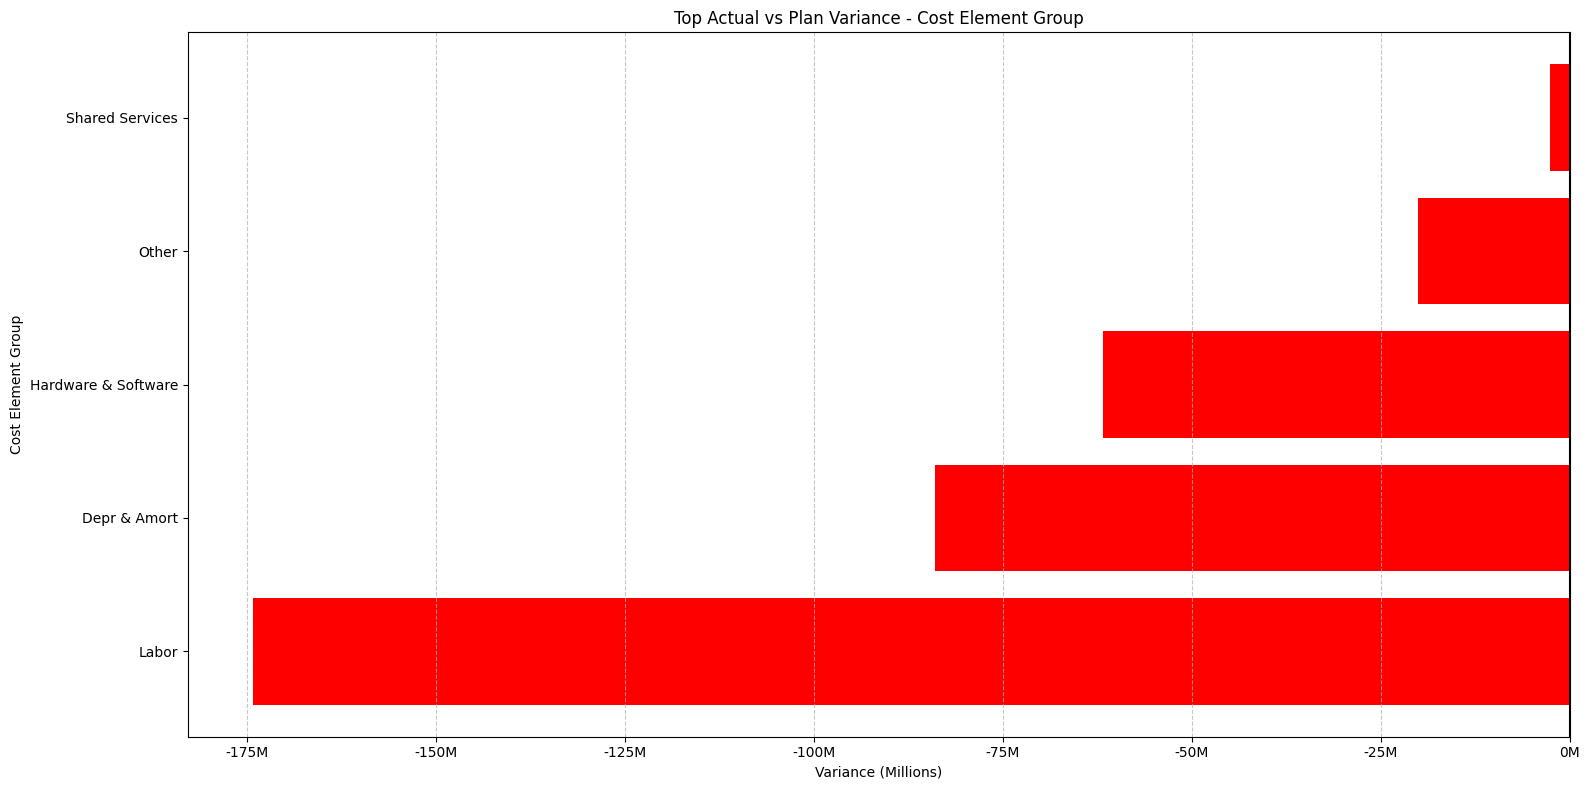

In [50]:
plt.figure(figsize=(16, 8))

top_cost_element_groups = cost_element_group_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_cost_element_groups["actual_vs_plan"]]
plt.barh(top_cost_element_groups["cost_element_group"], top_cost_element_groups["actual_vs_plan"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Group')
plt.xlabel('Variance (Millions)')
plt.title('Top Actual vs Plan Variance - Cost Element Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Cost Element Sub Group Analysis

In [51]:
cost_element_sub_group_analysis = (
    df.groupby("cost_element_sub_group")[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

cost_element_sub_group_analysis["actual_vs_forecast"] = (
    cost_element_sub_group_analysis["actual"] - cost_element_sub_group_analysis["forecast"]
)

cost_element_sub_group_analysis["actual_vs_plan"] = (
    cost_element_sub_group_analysis["actual"] - cost_element_sub_group_analysis["plan"]
)

cost_element_sub_group_analysis = cost_element_sub_group_analysis.sort_values(
    by="actual",
    ascending=False
)

print(cost_element_sub_group_analysis)

   cost_element_sub_group        actual      forecast          plan  \
3          External Labor  1.552107e+08  2.685034e+08  2.547992e+08   
7          Internal Labor  1.334513e+08  2.038884e+08  2.079605e+08   
0            Amortization  1.129124e+08  1.696250e+08  1.565869e+08   
16   Software Maintenance  4.980895e+07  7.838010e+07  8.408573e+07   
4                Hardware  2.856525e+07  3.672775e+07  4.482090e+07   
1            Depreciation  2.145569e+07  3.578781e+07  6.168952e+07   
15               Software  1.931407e+07  2.936025e+07  2.235995e+07   
19               Telecomm  1.298812e+07  1.872035e+07  9.412414e+06   
5    Hardware Maintenance  4.881066e+06  1.084553e+07  1.301985e+07   
21                 Travel  4.174654e+06  5.742037e+06  4.350335e+06   
10                  Other  3.197060e+06  1.829373e+07  2.663388e+07   
12       Project Expenses  2.213008e+06  2.645072e+06  1.659145e+06   
17               Supplies  1.415479e+06  1.291548e+06  1.721328e+06   
18    

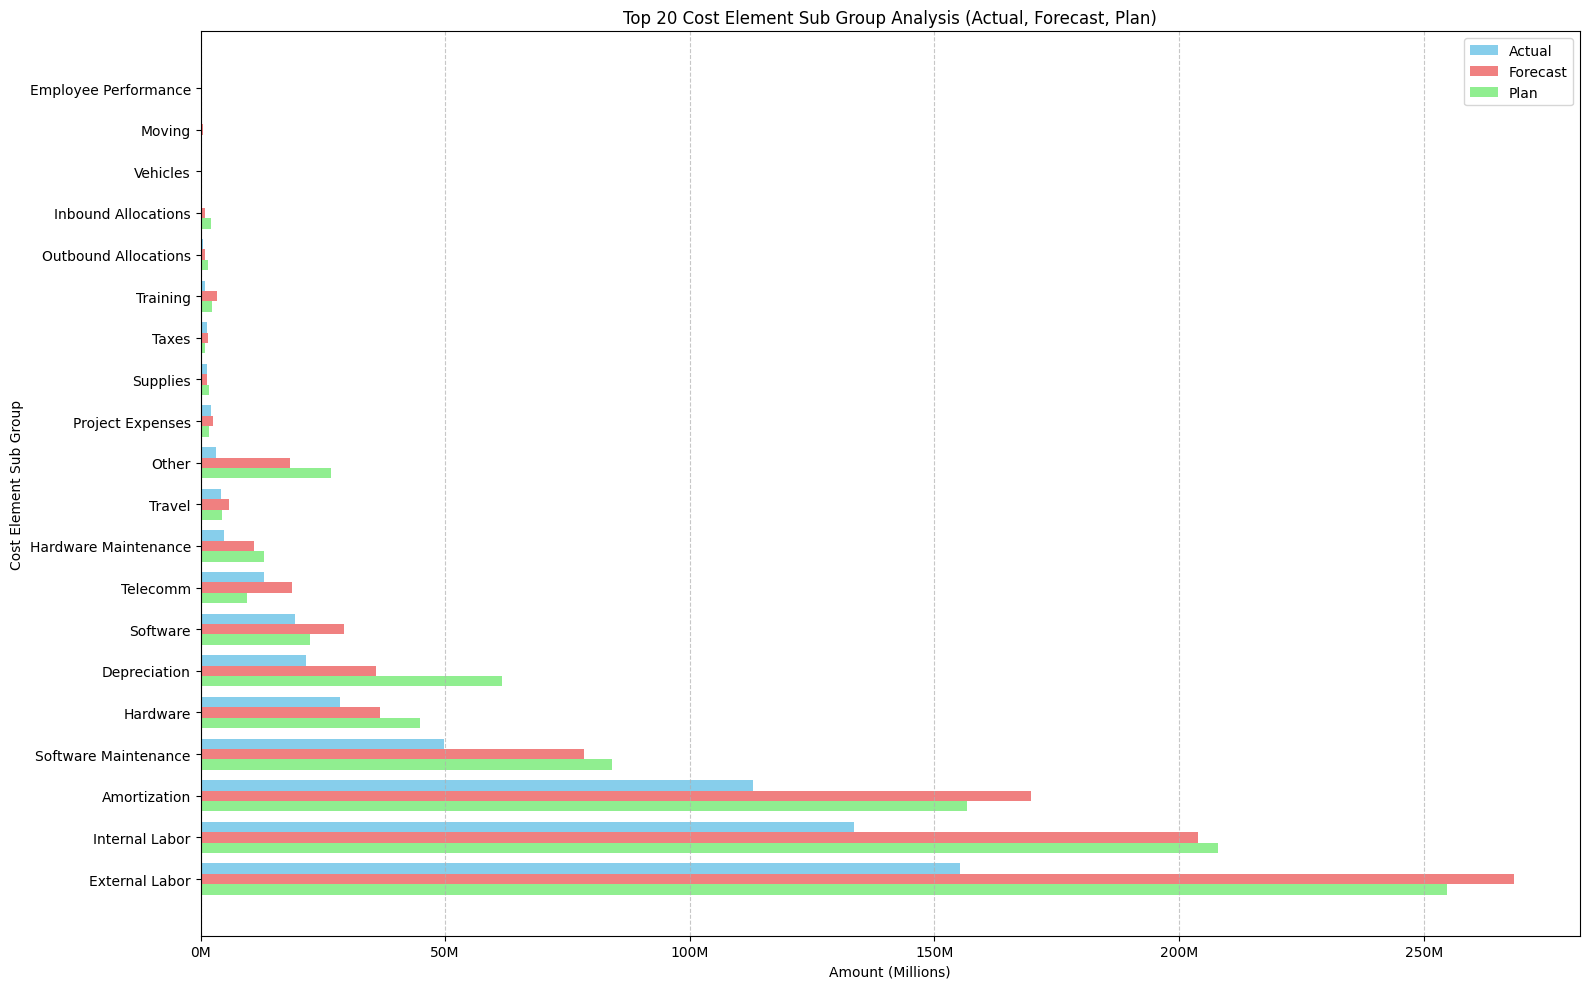

In [52]:
plt.figure(figsize=(16, 10))

top_20_cost_elements_sub_group = cost_element_sub_group_analysis.head(20)

bar_width = 0.25
index = np.arange(len(top_20_cost_elements_sub_group))

plt.barh(index + bar_width, top_20_cost_elements_sub_group["actual"], bar_width, label="Actual", color='skyblue')
plt.barh(index, top_20_cost_elements_sub_group["forecast"], bar_width, label="Forecast", color='lightcoral')
plt.barh(index - bar_width, top_20_cost_elements_sub_group["plan"], bar_width, label="Plan", color='lightgreen')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.yticks(index, top_20_cost_elements_sub_group["cost_element_sub_group"])
plt.ylabel('Cost Element Sub Group')
plt.xlabel('Amount (Millions)')
plt.title('Top 20 Cost Element Sub Group Analysis (Actual, Forecast, Plan)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

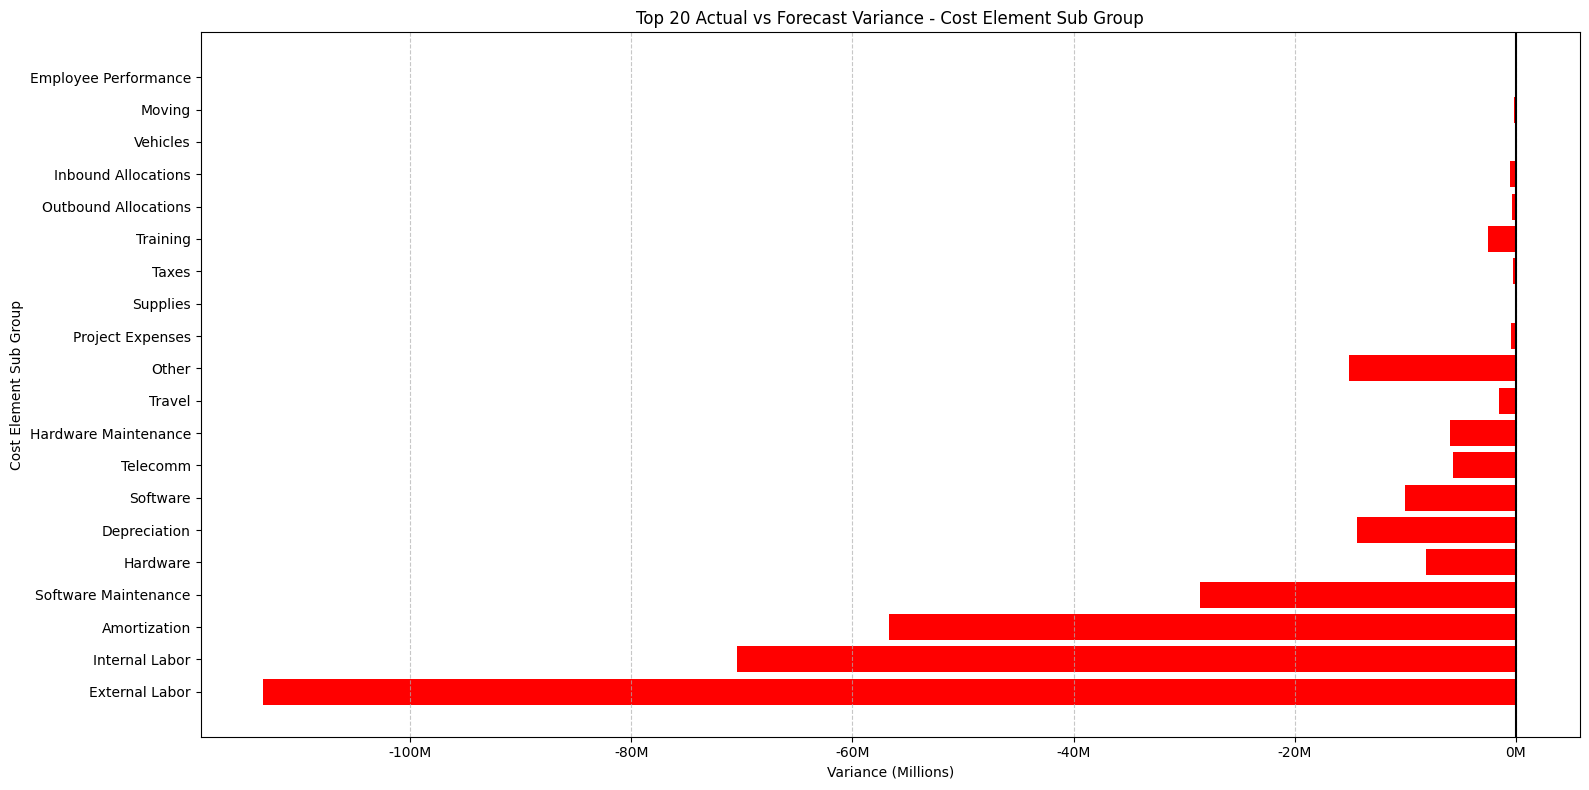

In [53]:
plt.figure(figsize=(16, 8))

top_20_cost_elements_sub_group = cost_element_sub_group_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_20_cost_elements_sub_group["actual_vs_forecast"]]
plt.barh(top_20_cost_elements_sub_group["cost_element_sub_group"], top_20_cost_elements_sub_group["actual_vs_forecast"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Sub Group')
plt.xlabel('Variance (Millions)')
plt.title('Top 20 Actual vs Forecast Variance - Cost Element Sub Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

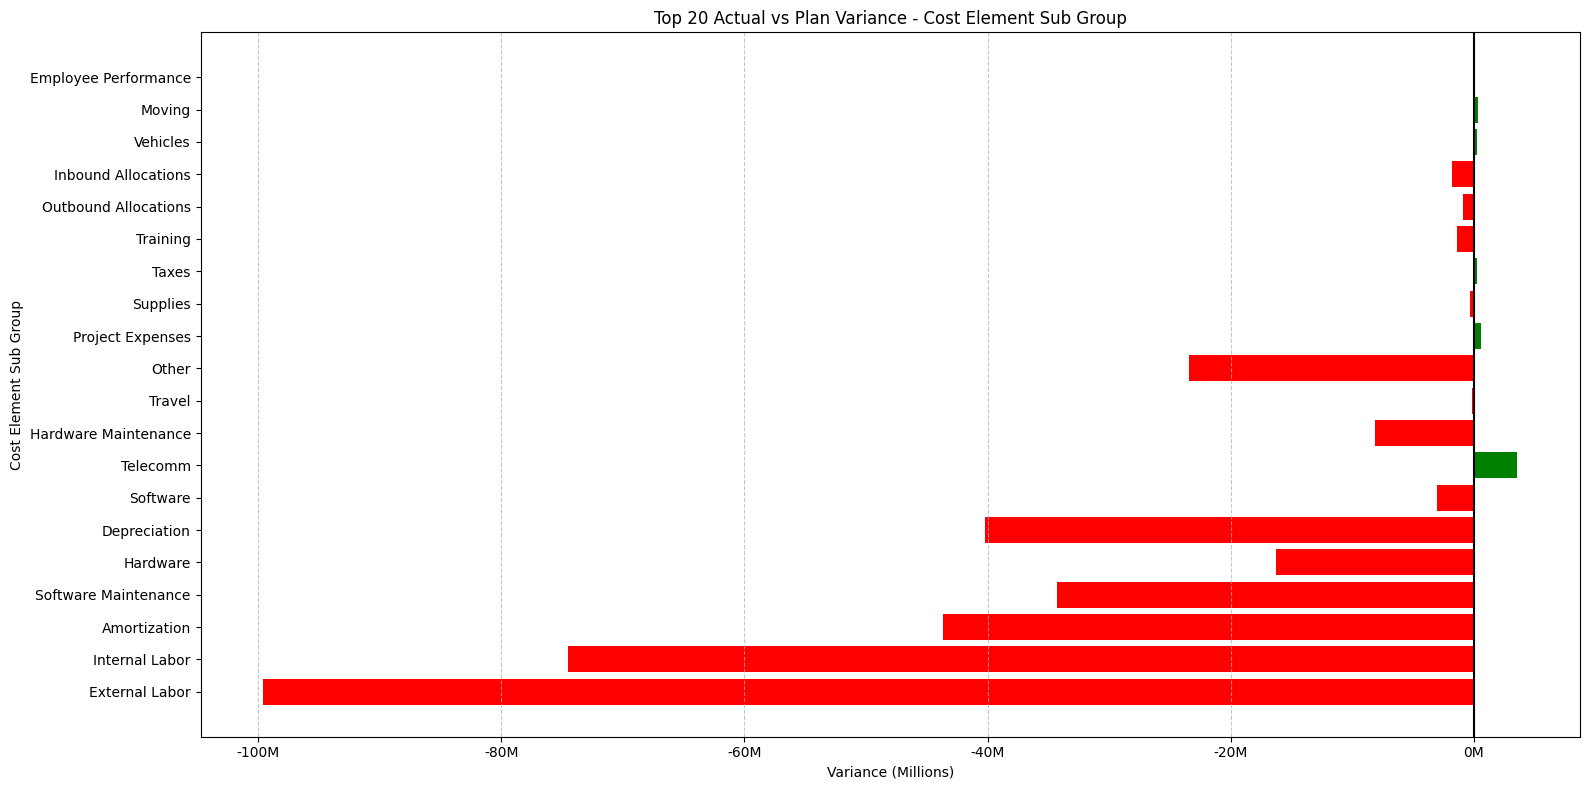

In [54]:
plt.figure(figsize=(16, 8))

top_20_cost_elements_sub_group = cost_element_sub_group_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_20_cost_elements_sub_group["actual_vs_plan"]]
plt.barh(top_20_cost_elements_sub_group["cost_element_sub_group"], top_20_cost_elements_sub_group["actual_vs_plan"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Sub Group')
plt.xlabel('Variance (Millions)')
plt.title('Top 20 Actual vs Plan Variance - Cost Element Sub Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Cost Element Name

In [55]:
cost_element_name_analysis = (
    df.groupby("cost_element_name")[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

cost_element_name_analysis["actual_vs_forecast"] = (
    cost_element_name_analysis["actual"] - cost_element_name_analysis["forecast"]
)

cost_element_name_analysis["actual_vs_plan"] = (
    cost_element_name_analysis["actual"] - cost_element_name_analysis["plan"]
)

cost_element_name_analysis = cost_element_name_analysis.sort_values(
    by="actual",
    ascending=False
)

print(cost_element_name_analysis)

              cost_element_name        actual      forecast          plan  \
161                    Software  1.129124e+08  1.696250e+08  1.565869e+08   
127       Professional Services  9.249596e+07  1.787045e+08  1.526554e+08   
136  Regular Salaries And Wages  8.452811e+07  1.580536e+08  1.622791e+08   
112                 Outsourcing  5.098157e+07  7.445513e+07  9.023271e+07   
162        Software Maintenance  4.980895e+07  7.838010e+07  8.408573e+07   
..                          ...           ...           ...           ...   
82            Misc. Credits - 2 -2.196360e+05 -2.163776e+05  0.000000e+00   
179   Time Charges - Activities -3.599786e+05 -2.526330e+05  0.000000e+00   
1                   Adjustments -7.268367e+05 -7.230939e+05  1.246260e+04   
83            Misc. Credits - 3 -1.034458e+06 -1.280788e+06 -5.531151e+05   
173                     Telecom -1.291278e+07 -1.872077e+07  1.874620e+06   

     actual_vs_forecast  actual_vs_plan  
161       -5.671264e+07    -43674

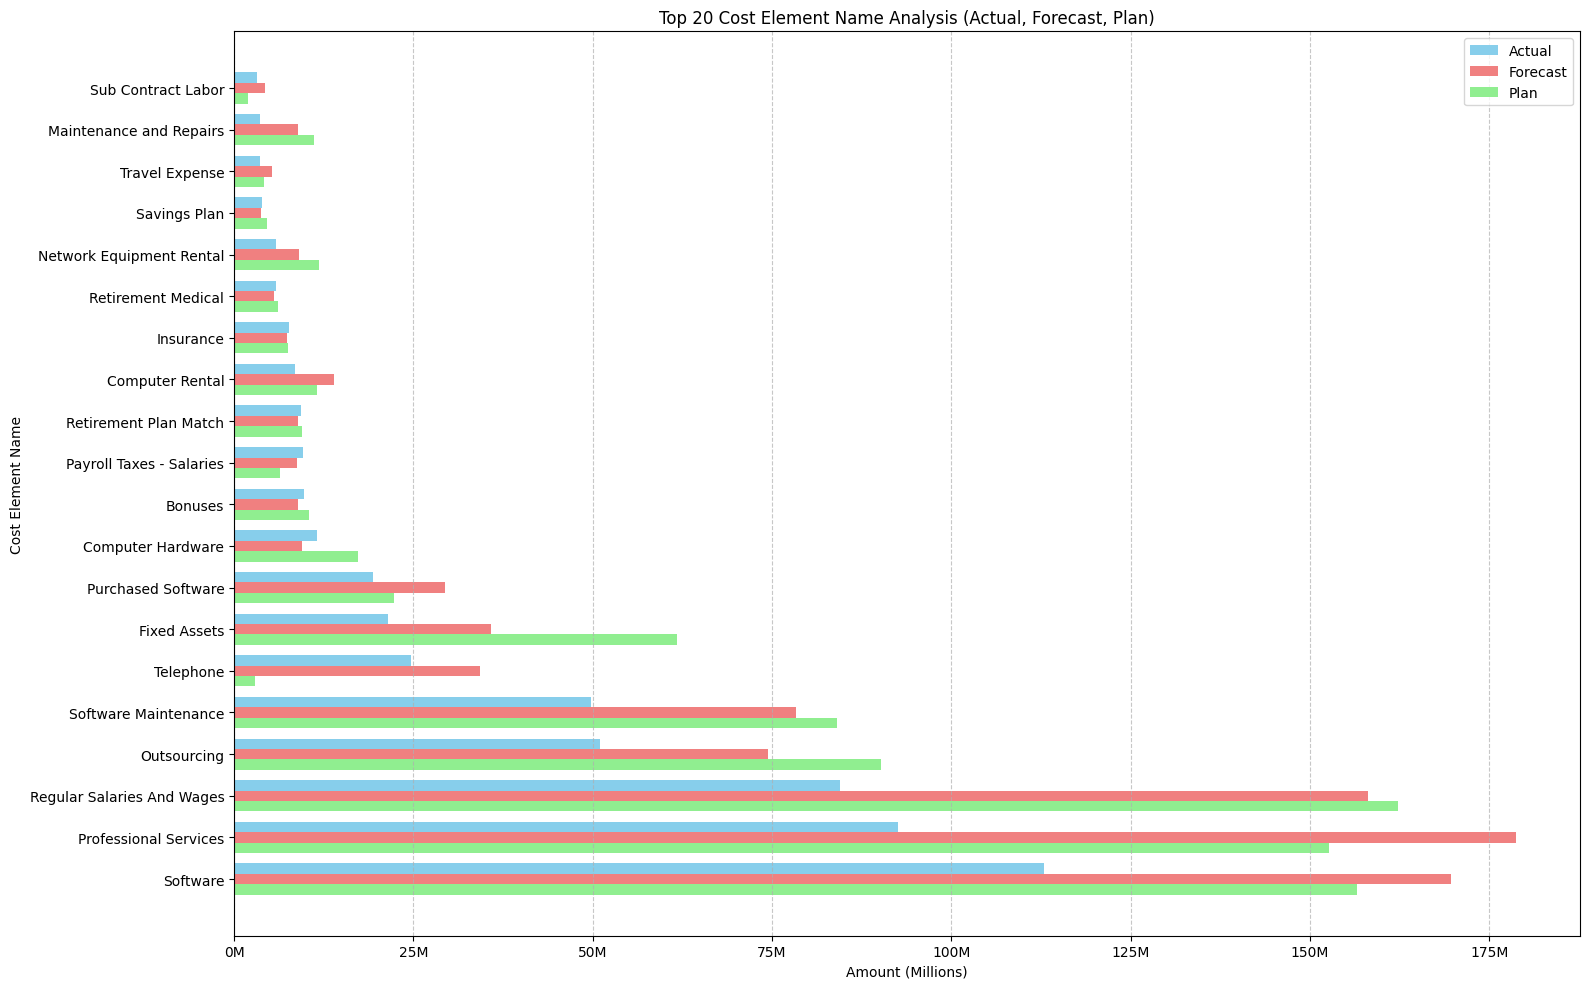

In [56]:
plt.figure(figsize=(16, 10))

top_20_cost_elements_name = cost_element_name_analysis.head(20)

bar_width = 0.25
index = np.arange(len(top_20_cost_elements_name))

plt.barh(index + bar_width, top_20_cost_elements_name["actual"], bar_width, label="Actual", color='skyblue')
plt.barh(index, top_20_cost_elements_name["forecast"], bar_width, label="Forecast", color='lightcoral')
plt.barh(index - bar_width, top_20_cost_elements_name["plan"], bar_width, label="Plan", color='lightgreen')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.yticks(index, top_20_cost_elements_name["cost_element_name"])
plt.ylabel('Cost Element Name')
plt.xlabel('Amount (Millions)')
plt.title('Top 20 Cost Element Name Analysis (Actual, Forecast, Plan)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

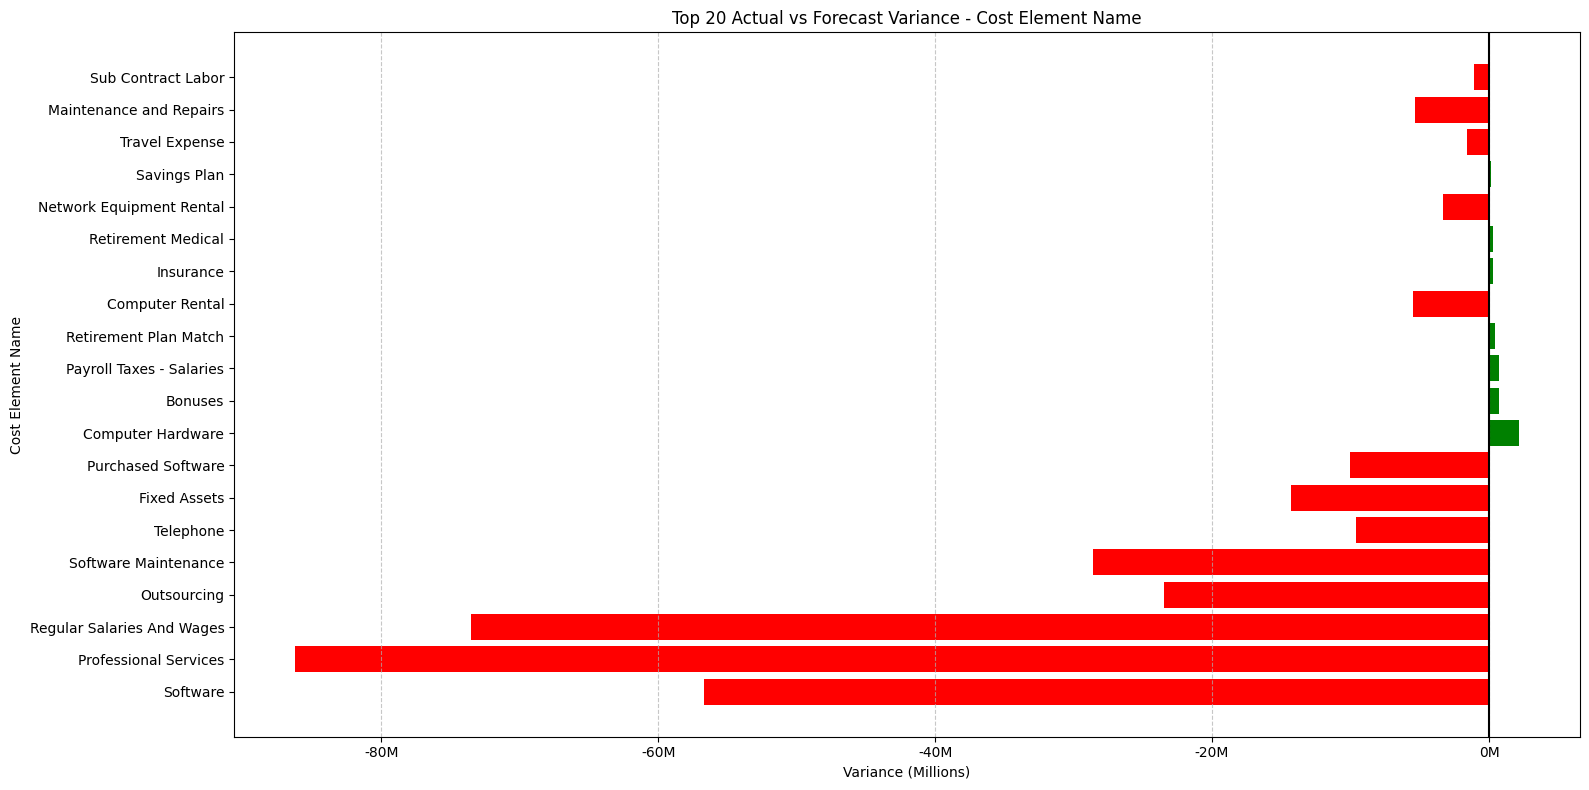

In [57]:
plt.figure(figsize=(16, 8))

top_20_cost_elements_name = cost_element_name_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_20_cost_elements_name["actual_vs_forecast"]]
plt.barh(top_20_cost_elements_name["cost_element_name"], top_20_cost_elements_name["actual_vs_forecast"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Name')
plt.xlabel('Variance (Millions)')
plt.title('Top 20 Actual vs Forecast Variance - Cost Element Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

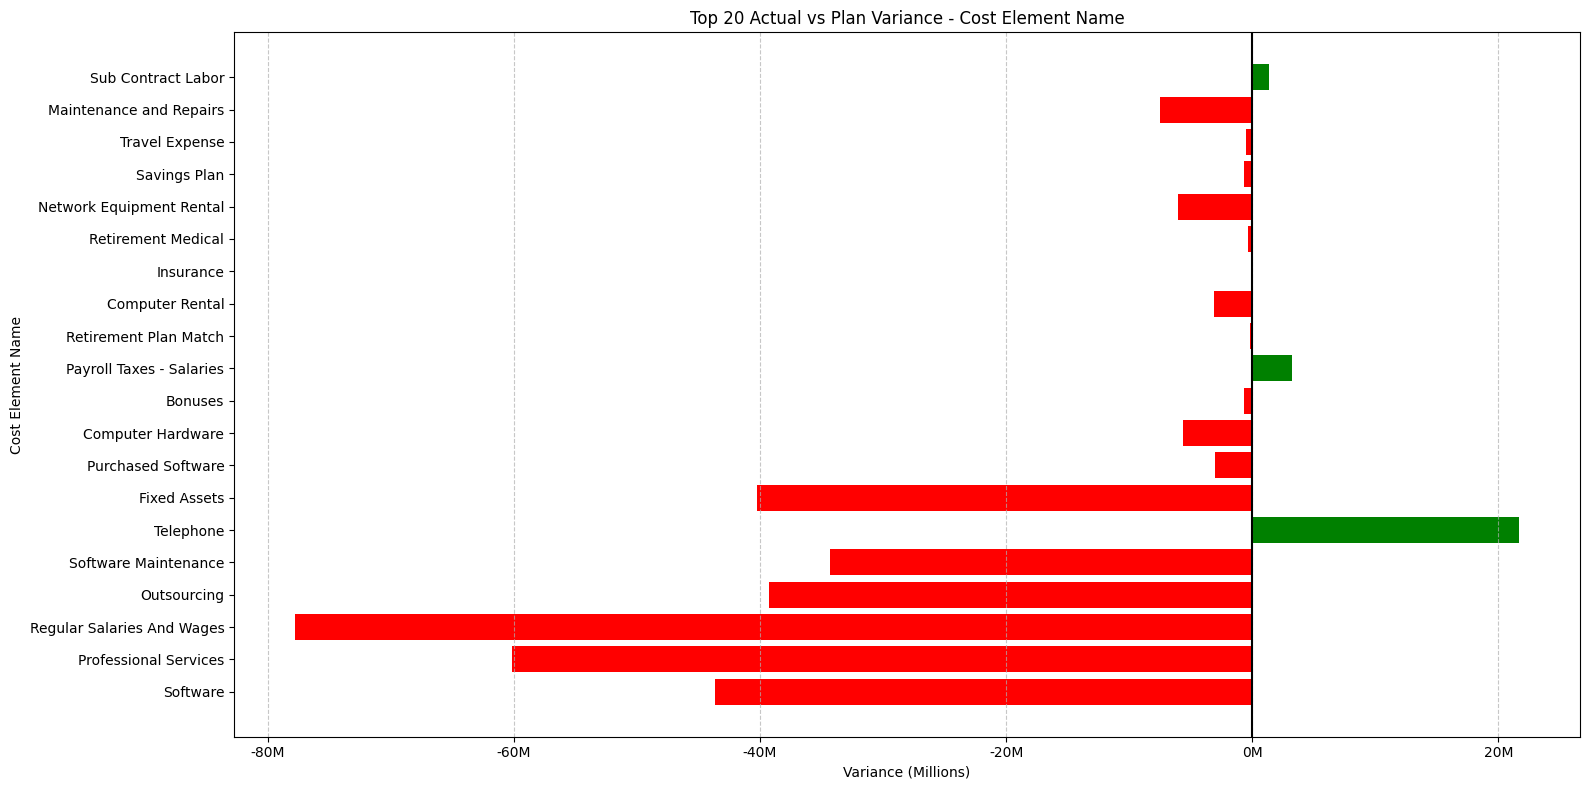

In [58]:
plt.figure(figsize=(16, 8))

top_20_cost_elements_name = cost_element_name_analysis.head(20)

colors = ['green' if x > 0 else 'red' for x in top_20_cost_elements_name["actual_vs_plan"]]
plt.barh(top_20_cost_elements_name["cost_element_name"], top_20_cost_elements_name["actual_vs_plan"], color=colors)
plt.axvline(0, color="black")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.ylabel('Cost Element Name')
plt.xlabel('Variance (Millions)')
plt.title('Top 20 Actual vs Plan Variance - Cost Element Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2D Analysis

## Business * Country

In [64]:
business_country = (
    df.groupby(["business_area", "country"])[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

business_country["actual_vs_plan"] = (
    business_country["actual"] - business_country["plan"]
)

business_country["actual_vs_forecast"] = (
    business_country["actual"] - business_country["forecast"]
)

business_country

,business_area,country,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
0,BU,Austria,176796.63,1.656617e+05,157170.84,19625.79,1.113490e+04
1,BU,Belgium,3646844.71,5.938383e+06,5572674.84,-1925830.13,-2.291538e+06
2,BU,Brazil,613118.83,8.299371e+05,829937.07,-216818.24,-2.168182e+05
3,BU,Canada,967942.73,1.519434e+06,1522654.76,-554712.03,-5.514913e+05
4,BU,Czech Republic,127845.65,0.000000e+00,0.00,127845.65,1.278457e+05
...,...,...,...,...,...,...,...
77,Services,Germany,215086.83,3.490570e+05,160902.24,54184.59,-1.339702e+05
78,Services,Italy,175670.62,3.838864e+05,379269.66,-203599.04,-2.082157e+05
79,Services,Spain,255303.51,2.897689e+05,160902.24,94401.27,-3.446534e+04
80,Services,USA,21498077.02,3.609560e+07,37990030.06,-16491953.04,-1.459753e+07


In [65]:
business_country = business_country.sort_values(
    by="actual_vs_plan",
    ascending=False
)

business_country.head(10)

,business_area,country,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
38,Infrastructure,Spain,2798620.05,2.240761e+06,1247964.64,1550655.41,557859.3814
23,Distribution,United Kingdom,1787924.95,2.054584e+06,1355644.80,432280.15,-266658.6574
15,BU,United Kingdom,3140198.10,2.822265e+06,2856306.72,283891.38,317933.0306
12,BU,Switzerland,342986.78,2.283157e+05,157500.00,185486.78,114671.0690
4,BU,Czech Republic,127845.65,0.000000e+00,0.00,127845.65,127845.6500
7,BU,Hungary,111811.38,0.000000e+00,0.00,111811.38,111811.3800
70,R&D,Germany,105528.50,9.613204e+04,0.00,105528.50,9396.4600
43,Manufacturing,Brazil,264021.38,1.639879e+05,163987.90,100033.48,100033.4797
79,Services,Spain,255303.51,2.897689e+05,160902.24,94401.27,-34465.3442
58,Office & Administrative,France,91062.97,8.971708e+04,0.00,91062.97,1345.8900


## Business Area * IT Area

In [66]:
ba_it = (
    df.groupby(["business_area", "it_area"])[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

ba_it["actual_vs_plan"] = (
    ba_it["actual"] - ba_it["plan"]
)

ba_it["actual_vs_forecast"] = (
    ba_it["actual"] - ba_it["forecast"]
)

ba_it

,business_area,it_area,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
0,BU,BU Support,1.035512e+07,1.498048e+07,1.291225e+07,-2557129.96,-4.625356e+06
1,BU,Functional,6.719729e+07,1.203696e+08,1.260016e+08,-58804328.80,-5.317231e+07
2,Distribution,Governance,3.288038e+07,5.229149e+07,5.177806e+07,-18897679.53,-1.941111e+07
3,Infrastructure,BU Support,1.348047e+04,0.000000e+00,0.000000e+00,13480.47,1.348047e+04
4,Infrastructure,Enablement,2.904889e+06,5.198166e+06,7.954664e+06,-5049774.68,-2.293277e+06
5,Infrastructure,Infrastructure,1.548086e+08,2.368272e+08,2.416131e+08,-86804473.12,-8.201858e+07
6,Manufacturing,BU Support,8.665847e+07,1.337034e+08,1.304895e+08,-43830994.20,-4.704491e+07
7,Office & Administrative,Functional,1.111826e+08,1.723924e+08,1.726290e+08,-61446314.76,-6.120978e+07
8,Office & Administrative,Governance,1.740000e+02,1.740000e+02,0.000000e+00,174.00,0.000000e+00
9,R&D,BU Support,6.553644e+07,1.146429e+08,1.134918e+08,-47955333.10,-4.910642e+07


In [68]:
ba_it = ba_it.sort_values(
    by="actual_vs_plan"
)

ba_it.head(10)

,business_area,it_area,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
5,Infrastructure,Infrastructure,1.548086e+08,2.368272e+08,2.416131e+08,-86804473.12,-8.201858e+07
7,Office & Administrative,Functional,1.111826e+08,1.723924e+08,1.726290e+08,-61446314.76,-6.120978e+07
1,BU,Functional,6.719729e+07,1.203696e+08,1.260016e+08,-58804328.80,-5.317231e+07
9,R&D,BU Support,6.553644e+07,1.146429e+08,1.134918e+08,-47955333.10,-4.910642e+07
6,Manufacturing,BU Support,8.665847e+07,1.337034e+08,1.304895e+08,-43830994.20,-4.704491e+07
2,Distribution,Governance,3.288038e+07,5.229149e+07,5.177806e+07,-18897679.53,-1.941111e+07
10,Services,Enablement,2.243617e+07,3.775176e+07,3.958379e+07,-17147619.22,-1.531559e+07
4,Infrastructure,Enablement,2.904889e+06,5.198166e+06,7.954664e+06,-5049774.68,-2.293277e+06
0,BU,BU Support,1.035512e+07,1.498048e+07,1.291225e+07,-2557129.96,-4.625356e+06
8,Office & Administrative,Governance,1.740000e+02,1.740000e+02,0.000000e+00,174.00,0.000000e+00


## IT Area * IT Sub Area

In [70]:
it_subit = (
    df.groupby(["it_area", "it_sub_area"])[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

it_subit["actual_vs_plan"] = (
    it_subit["actual"] - it_subit["plan"]
)

it_subit["actual_vs_forecast"] = (
    it_subit["actual"] - it_subit["forecast"]
)

it_subit

,it_area,it_sub_area,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
0,BU Support,Core,9.136615e+05,1.922684e+06,8.174030e+05,96258.47,-1.009023e+06
1,BU Support,Development,8.415825e+06,1.930143e+07,2.209553e+07,-13679704.48,-1.088561e+07
2,BU Support,Distribution,7.011607e+06,8.684125e+06,8.540073e+06,-1528466.32,-1.672518e+06
3,BU Support,Emerging,2.341956e+06,3.412064e+06,3.397279e+06,-1055322.53,-1.070108e+06
4,BU Support,Manufacturing,8.665847e+07,1.337034e+08,1.304895e+08,-43830994.20,-4.704491e+07
5,BU Support,Planning,4.849051e+07,7.662304e+07,7.472699e+07,-26236482.82,-2.813253e+07
6,BU Support,Production,1.013809e+05,9.616072e+05,1.575000e+05,-56119.11,-8.602263e+05
7,BU Support,R&D,8.630105e+06,1.871839e+07,1.666925e+07,-8039145.80,-1.008828e+07
8,Enablement,Business Intelligence,2.096726e+06,3.297388e+06,3.193986e+06,-1097260.14,-1.200662e+06
9,Enablement,Data Management,2.998525e+05,4.967102e+05,3.218045e+05,-21951.99,-1.968577e+05


In [71]:
it_subit = it_subit.sort_values(
    by="actual_vs_plan"
)

it_subit.head(10)

,it_area,it_sub_area,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
18,Functional,R2,1.111826e+08,1.723924e+08,1.726290e+08,-61446314.76,-6.120978e+07
4,BU Support,Manufacturing,8.665847e+07,1.337034e+08,1.304895e+08,-43830994.20,-4.704491e+07
19,Functional,R3,3.331415e+07,5.769880e+07,6.621891e+07,-32904764.75,-2.438466e+07
5,BU Support,Planning,4.849051e+07,7.662304e+07,7.472699e+07,-26236482.82,-2.813253e+07
31,Infrastructure,Data Centers,2.994646e+07,5.183462e+07,5.550741e+07,-25560952.61,-2.188816e+07
20,Functional,R5,2.950045e+07,5.373320e+07,5.067651e+07,-21176062.57,-2.423275e+07
36,Infrastructure,Productivity,4.185471e+07,4.786500e+07,5.797867e+07,-16123961.46,-6.010291e+06
30,Infrastructure,Core Infrastructure,1.259255e+07,3.088580e+07,2.681736e+07,-14224809.13,-1.829325e+07
1,BU Support,Development,8.415825e+06,1.930143e+07,2.209553e+07,-13679704.48,-1.088561e+07
33,Infrastructure,Hosting,2.095378e+07,3.172849e+07,3.436594e+07,-13412169.74,-1.077471e+07


## Country * IT Area

In [72]:
country_itarea = (
    df.groupby(["it_area", "country"])[["actual", "forecast", "plan"]]
      .sum()
      .reset_index()
)

country_itarea["actual_vs_plan"] = (
    country_itarea["actual"] - country_itarea["plan"]
)

country_itarea["actual_vs_forecast"] = (
    country_itarea["actual"] - country_itarea["forecast"]
)

country_itarea = country_itarea.sort_values(
    by="actual_vs_plan"
)

country_itarea.head(10)

,it_area,country,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
36,Functional,USA,1.632652e+08,2.689852e+08,2.732189e+08,-1.099537e+08,-1.057200e+08
15,BU Support,USA,1.338212e+08,2.170468e+08,2.152032e+08,-8.138195e+07,-8.322564e+07
62,Infrastructure,USA,1.147149e+08,1.710102e+08,1.780867e+08,-6.337183e+07,-5.629528e+07
22,Enablement,USA,2.347037e+07,4.030885e+07,4.588697e+07,-2.241660e+07,-1.683847e+07
44,Governance,USA,2.777506e+07,4.536552e+07,4.553032e+07,-1.775526e+07,-1.759047e+07
63,Infrastructure,United Kingdom,1.433818e+07,2.499128e+07,2.215628e+07,-7.818102e+06,-1.065310e+07
5,BU Support,France,9.887508e+06,1.444286e+07,1.431003e+07,-4.422523e+06,-4.555353e+06
37,Functional,United Kingdom,7.494678e+06,1.036360e+07,1.165393e+07,-4.159252e+06,-2.868921e+06
11,BU Support,Puerto Rico,6.214331e+06,9.605560e+06,9.357783e+06,-3.143452e+06,-3.391229e+06
51,Infrastructure,France,2.735088e+06,5.795949e+06,5.733100e+06,-2.998012e+06,-3.060860e+06


##PIVOT 2D Analysis

In [87]:
analysis_df = df.copy()

In [88]:
analysis_df["actual"] = analysis_df["actual"].fillna(0)
analysis_df["forecast"] = analysis_df["forecast"].fillna(0)
analysis_df["plan"] = analysis_df["plan"].fillna(0)

In [89]:
analysis_df["actual_vs_plan"] = (
    analysis_df["actual"] - analysis_df["plan"]
)

analysis_df["actual_vs_forecast"] = (
    analysis_df["actual"] - analysis_df["forecast"]
)

In [90]:
analysis_df[
    ["actual", "forecast", "plan", "actual_vs_plan", "actual_vs_forecast"]
].head(10)

,actual,forecast,plan,actual_vs_plan,actual_vs_forecast
0,0.00,0.00,-5805.03,5805.03,0.00
1,61.56,0.00,0.00,61.56,61.56
2,0.00,61.56,0.00,0.00,-61.56
3,0.00,0.00,270.01,-270.01,0.00
4,0.00,0.00,-10692.07,10692.07,0.00
5,0.00,0.00,-2025.01,2025.01,0.00
6,2693.00,0.00,0.00,2693.00,2693.00
7,0.00,2693.00,0.00,0.00,-2693.00
8,0.00,0.00,16125.10,-16125.10,0.00
9,73.93,0.00,0.00,73.93,73.93


In [91]:
pivot_ba_country = analysis_df.pivot_table(
    index="business_area",
    columns="country",
    values="actual_vs_plan",
    aggfunc="sum",
    fill_value=0
)

pivot_ba_country

country,Austria,Belgium,Brazil,Canada,China,Czech Republic,France,Germany,Hungary,Ireland,...,Mexico,Netherlands,New Zealand,Puerto Rico,Slovakia,Spain,Switzerland,Turkey,USA,United Kingdom
business_area,,,,,,,,,,,,,,,,,,,,,
BU,19625.79,-1925830.13,-216818.24,-554712.03,0.0,127845.65,-578603.66,-201743.51,111811.38,0.00,...,-651864.80,0.00,0.00,-298235.45,0.00,-553835.81,185486.78,4116.44,-55415567.51,283891.38
Distribution,0.00,0.00,0.00,0.00,0.0,0.00,-91479.88,-387224.83,0.00,0.00,...,0.00,0.00,-292498.84,0.00,0.00,-364253.61,0.00,0.00,-17755432.66,432280.15
Infrastructure,-555902.55,-294987.76,-2810856.81,-1149232.44,0.0,3625.79,-2998011.70,-489986.54,-4257.99,-2735793.03,...,-1318624.01,-439825.54,-2661880.90,0.00,1918.17,1550655.41,-677716.69,13480.47,-69296479.36,-6943229.81
Manufacturing,0.00,0.00,100033.48,0.00,0.0,0.00,-3397378.09,-273510.56,0.00,-961795.61,...,-229272.74,0.00,0.00,-3143452.12,0.00,-175893.03,0.00,0.00,-34312867.64,-208991.64
Office & Administrative,0.00,-41707.36,-815999.63,0.00,0.0,0.00,91062.97,-40942.38,0.00,0.00,...,-35956.16,0.00,0.00,0.00,0.00,-110933.05,-111434.19,0.00,-55634915.07,-4736613.32
R&D,0.00,43170.59,-26023.78,0.00,0.0,0.00,-423566.89,105528.50,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,-408343.73,0.00,0.00,-45972147.78,-1183042.77
Services,-123651.90,5394.03,0.00,0.00,0.0,0.00,0.00,54184.59,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,94401.27,0.00,0.00,-16491953.04,-482395.13


In [92]:
top_countries = (
    analysis_df.groupby("country")["actual_vs_plan"]
    .sum()
    .sort_values()
    .head(5)
    .index
)

pivot_ba_country[top_countries]

country,USA,United Kingdom,France,Italy,Brazil
business_area,,,,,
BU,-55415567.51,283891.38,-578603.66,-1697025.04,-216818.24
Distribution,-17755432.66,432280.15,-91479.88,-459116.02,0.00
Infrastructure,-69296479.36,-6943229.81,-2998011.70,-1033662.04,-2810856.81
Manufacturing,-34312867.64,-208991.64,-3397378.09,-1227866.25,100033.48
Office & Administrative,-55634915.07,-4736613.32,91062.97,-8702.57,-815999.63
R&D,-45972147.78,-1183042.77,-423566.89,-90907.24,-26023.78
Services,-16491953.04,-482395.13,0.00,-203599.04,0.00


## Infrastructure * Business Area

In [93]:
infra_it = (
    analysis_df[analysis_df["business_area"] == "Infrastructure"]
    .groupby("it_area")[["actual", "forecast", "plan", "actual_vs_plan"]]
    .sum()
    .sort_values(by="actual_vs_plan")
    .reset_index()
)

infra_it

,it_area,actual,forecast,plan,actual_vs_plan
0,Infrastructure,1.548086e+08,2.368272e+08,2.416131e+08,-86804473.12
1,Enablement,2.904889e+06,5.198166e+06,7.954664e+06,-5049774.68
2,BU Support,1.348047e+04,0.000000e+00,0.000000e+00,13480.47


In [94]:
infra_sub = (
    analysis_df[
        (analysis_df["business_area"] == "Infrastructure") &
        (analysis_df["it_area"] == "Infrastructure")
    ]
    .groupby("it_sub_area")[["actual_vs_plan"]]
    .sum()
    .sort_values(by="actual_vs_plan")
    .reset_index()
)

infra_sub

,it_sub_area,actual_vs_plan
0,Data Centers,-25560952.61
1,Productivity,-16123961.46
2,Core Infrastructure,-14224809.13
3,Hosting,-13412169.74
4,Networking,-9058292.13
5,Help Desk,-6270304.50
6,SSO,-2156083.09
7,Licensing,2099.54


In [96]:
infra_ceg = (
    analysis_df[
        (analysis_df["business_area"] == "Infrastructure") &
        (analysis_df["it_area"] == "Infrastructure") &
        (analysis_df["it_sub_area"] == "Data Centers")
    ]
    .groupby("cost_element_group")[["actual_vs_plan"]]
    .sum()
    .sort_values(by="actual_vs_plan")
    .reset_index()
)

infra_ceg

,cost_element_group,actual_vs_plan
0,Hardware & Software,-11580291.06
1,Labor,-8806660.87
2,Depr & Amort,-4807685.34
3,Other,-366315.34


##Visualization 2D Analysis

In [97]:
ba_variance = (
    analysis_df.groupby("business_area")["actual_vs_plan"]
    .sum()
    .sort_values()
    .reset_index()
)

ba_variance

,business_area,actual_vs_plan
0,Infrastructure,-91840767.33
1,Office & Administrative,-61446140.76
2,BU,-61361458.76
3,R&D,-47955333.10
4,Manufacturing,-43830994.20
5,Distribution,-18897679.53
6,Services,-17147619.22


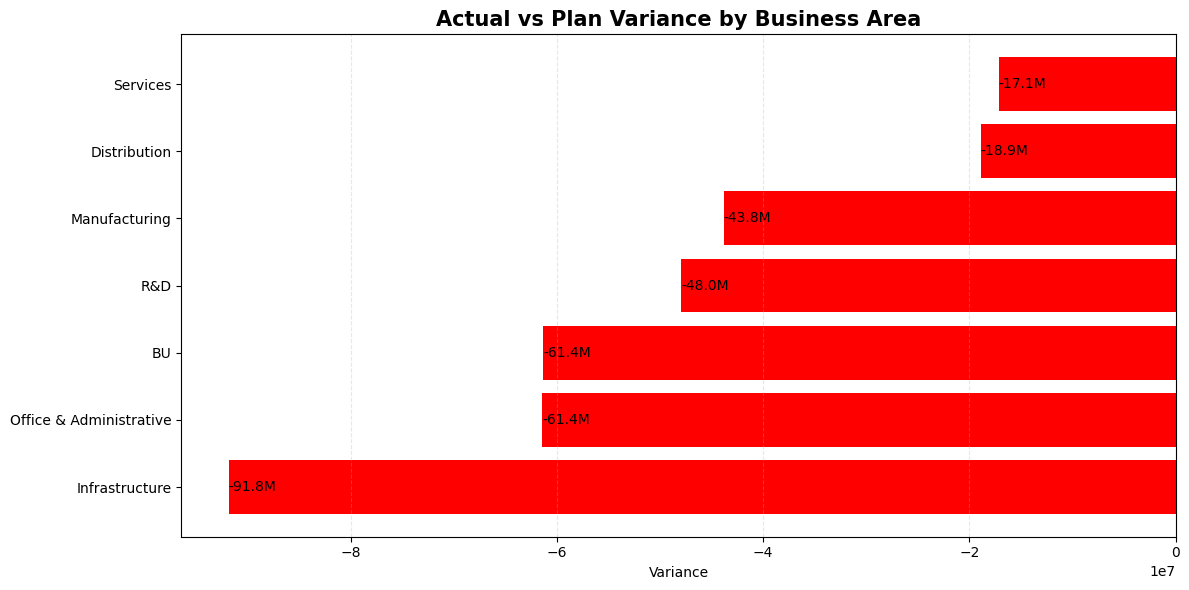

In [99]:
import matplotlib.pyplot as plt

colors = [
    "red" if x < 0 else "green"
    for x in ba_variance["actual_vs_plan"]
]

plt.figure(figsize=(12, 6))

bars = plt.barh(
    ba_variance["business_area"],
    ba_variance["actual_vs_plan"],
    color=colors
)

plt.title("Actual vs Plan Variance by Business Area", fontsize=15, fontweight="bold")
plt.xlabel("Variance")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width/1e6:.1f}M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [100]:
ba_compare = (
    analysis_df.groupby("business_area")[["actual", "plan"]]
    .sum()
    .sort_values(by="actual", ascending=False)
    .reset_index()
)

ba_compare

,business_area,actual,plan
0,Infrastructure,1.577270e+08,2.495678e+08
1,Office & Administrative,1.111828e+08,1.726290e+08
2,Manufacturing,8.665847e+07,1.304895e+08
3,BU,7.755242e+07,1.389139e+08
4,R&D,6.553644e+07,1.134918e+08
5,Distribution,3.288038e+07,5.177806e+07
6,Services,2.243617e+07,3.958379e+07


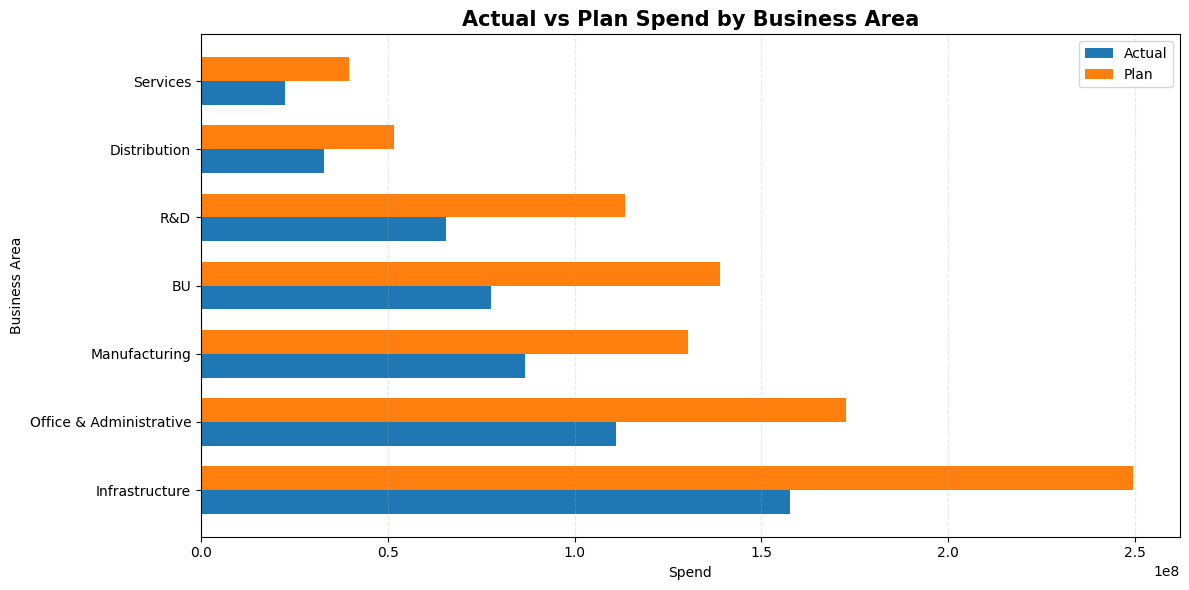

In [101]:
import numpy as np
import matplotlib.pyplot as plt

y = np.arange(len(ba_compare))
bar_width = 0.35

plt.figure(figsize=(12,6))

plt.barh(
    y - bar_width/2,
    ba_compare["actual"],
    height=bar_width,
    label="Actual"
)

plt.barh(
    y + bar_width/2,
    ba_compare["plan"],
    height=bar_width,
    label="Plan"
)

plt.yticks(y, ba_compare["business_area"])

plt.title("Actual vs Plan Spend by Business Area",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Spend")
plt.ylabel("Business Area")

plt.legend()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

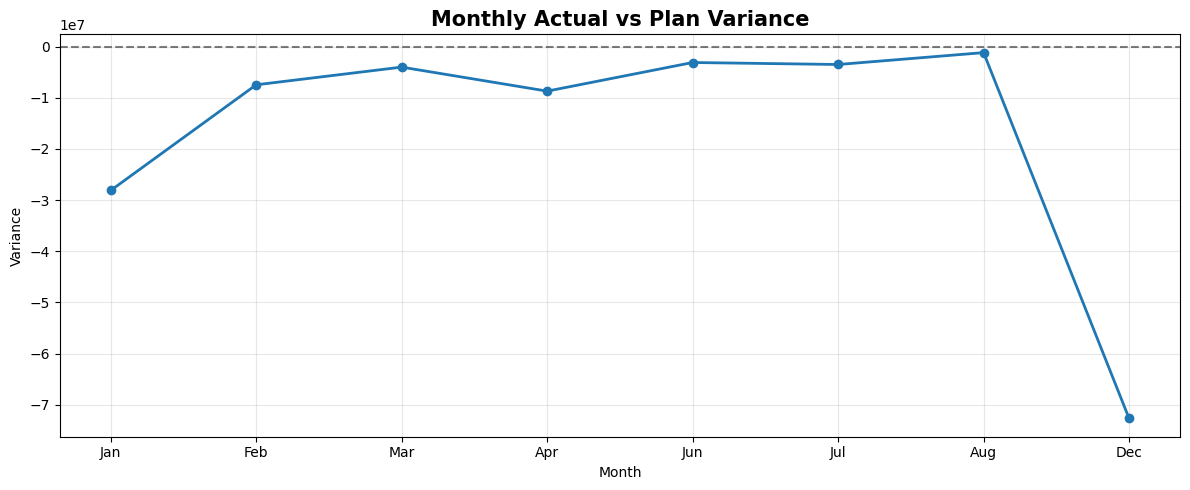

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["actual_vs_plan"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Monthly Actual vs Plan Variance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Variance")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [105]:
root_cause = (
    analysis_df[
        (analysis_df["business_area"] == "Infrastructure") &
        (analysis_df["it_area"] == "Infrastructure") &
        (analysis_df["it_sub_area"] == "Data Centers")
    ]
    .groupby("cost_element_group")["actual_vs_plan"]
    .sum()
    .sort_values()
    .reset_index()
)

root_cause

,cost_element_group,actual_vs_plan
0,Hardware & Software,-11580291.06
1,Labor,-8806660.87
2,Depr & Amort,-4807685.34
3,Other,-366315.34


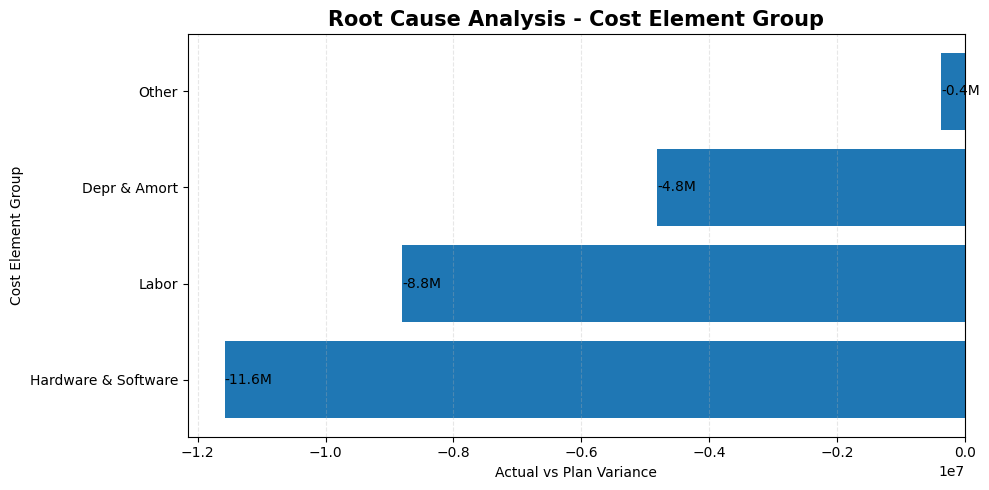

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.barh(
    root_cause["cost_element_group"],
    root_cause["actual_vs_plan"]
)

plt.title(
    "Root Cause Analysis - Cost Element Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual vs Plan Variance")
plt.ylabel("Cost Element Group")

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width/1e6:.1f}M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Insight 1
Observation

Infrastructure Business Area recorded the highest negative Actual vs Plan variance.

Insight

Infrastructure is the primary contributor to the organization's budget overspend and requires immediate investigation.

Recommendation

Prioritize a detailed cost review of the Infrastructure Business Area and identify high-impact spending categories.

Insight 2
Observation

Within the Infrastructure Business Area, the Infrastructure IT Area contributed the highest variance.

Insight

The overspend is concentrated within a specific IT Area rather than being evenly distributed across all Infrastructure functions.

Recommendation

Perform a detailed budget review for the Infrastructure IT Area and validate resource allocation.

Observation

Within the Infrastructure IT Area, the Data Center IT Sub Area generated the highest negative variance.

Insight

Data Center operations are the major driver of Infrastructure overspending.

Recommendation

Review Data Center operational expenses, vendor contracts, and infrastructure utilization.

Observation

Within the Data Center IT Sub Area, the Hardware & Software Cost Element Group contributed the largest negative variance.

Insight

Hardware and Software related expenditures are the primary root cause of the overall budget variance.

Recommendation

Review procurement practices, software licensing costs, hardware purchases, and vendor agreements to identify cost optimization opportunities.